# BRSET Glaucoma — R19 MLP (PCA-384 + MI Feature Selection + Dual Threshold)

**Upgrades over R18:**
- PCA bumped 256-D → 384-D — retains ~99.5%+ variance, recovers discriminative signal lost in R18
- Mutual Information (MI) feature selection on PCA components — keeps only the most predictive dims
- Dual-threshold strategy — tries BOTH raw and calibrated probabilities, picks the one with best val F1
- BayesSearchCV 35 → 50 iterations — deeper hyperparameter exploration
- All other R18 improvements retained (25 bags, isotonic calibration, 6 aggregation methods)

**Pipeline per embedding (no cross-embedding fusion):**
1. Load embedding + clinical metadata (age, sex, diabetes, exam_eye, camera)
2. PCA reduce embedding to 384-D
3. MI feature selection — keep top-K PCA components (K chosen by elbow)
4. Concatenate MI-selected PCA + metadata, scale
5. BayesSearchCV on image-level MLP → find best hyperparams (50 iters)
6. Bagging: 5 seeds × 5 architectures = 25 sub-models → average image-level probas
7. Isotonic calibration on inner validation set
8. **Dual threshold**: sweep aggregation × threshold on BOTH raw + calibrated probas, pick best
9. Final evaluation on held-out test patients

**Data:** Cleaned BRSET (14,254 images, 8,061 patients, 19.9% glaucoma+)  
**Features:** MI-selected PCA embedding + clinical metadata (5 cols)  
**Split:** Frozen 80/20 patient split from original experiment  
**Task:** `increased_cup_disc` (glaucoma surrogate)

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 1 — Imports  (R19: added mutual_info_classif for MI feature selection)
# ═══════════════════════════════════════════════════════════════════════
import os, sys, json, time, warnings, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LogNorm

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score,
 )
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import mutual_info_classif   # R19: MI feature selection

sys.path.insert(0, str(Path.cwd() / 'src'))
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK  (PCA + IsotonicRegression + mutual_info_classif loaded)')

Imports OK  (PCA + IsotonicRegression + mutual_info_classif loaded)


In [5]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 2 — Configuration  (R19 rev: tightened HP ranges to reduce overfitting)
# ═══════════════════════════════════════════════════════════════════════

# ─── Paths ────────────────────────────────────────────────────────
DATASET_NAME = 'brset'
TASK = 'increased_cup_disc'       # glaucoma proxy  (binary target)
PCA_COMPONENTS = 384              # enough for all 7 embeddings
MI_SELECTION = True
MI_PERCENTILE_THRESH = 0.15       # drop bottom 15% by MI
MI_MIN_COMPONENTS = 128           # never drop below 128
RANDOM_SEED = 42

from multiprocessing import cpu_count
CPU_COUNT = cpu_count()

BASE_DIR = Path.cwd()
EMBED_DIR = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'
RESULTS_DIR = BASE_DIR / 'results' / 'brset'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_CSV = BASE_DIR / 'results' / 'brset_patient_eval_glaucoma' / 'patient_split.csv'
ORIG_P1_CSV  = BASE_DIR / 'results' / 'brset_patient_eval_glaucoma' / 'summary.csv'
ORIG_P2_CSV  = BASE_DIR / 'results' / 'brset_patient_eval_glaucoma' / 'phase2_refinement' / 'phase2_summary.csv'

# ─── Architecture search space ────────────────────────────────────
# Tuned for MI-selected PCA input (~250-350 dims after MI + 5 meta)
ARCHITECTURE_OPTIONS = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
    (128, 64), (384, 192),
    (384, 192, 96),
]

# ─── Overfitting-aware search space (R27-fix) ────────────────────
# OLD ranges allowed alpha=1e-5 (no regularization) and LR=0.01
# (rapid memorization).  Tightened to enforce meaningful L2 and
# cap learning rate.
SEARCH_SPACE = {
    'hidden_layer_sizes': Categorical(list(range(len(ARCHITECTURE_OPTIONS)))),
    'alpha': Real(1e-3, 1.0, prior='log-uniform'),           # was (1e-5, 1e-1)
    'learning_rate_init': Real(1e-4, 2e-3, prior='log-uniform'),  # was (1e-5, 1e-2)
    'batch_size': Categorical([64, 128, 256]),
    'pos_class_weight': Real(1.0, 10.0, prior='uniform'),
}

# ─── R19 tuning params ────────────────────────────────────────────
BAYES_N_ITER  = 50        # ↑ from 35 — deeper HP search
BAYES_CV_FOLDS = 3
BAYES_N_JOBS  = min(3, CPU_COUNT)
MLP_MAX_ITER  = 600       # was 400 — headroom for adaptive LR's multi-phase training
MLP_PATIENCE  = 30        # with adaptive LR: 30 stall epochs → LR/5 → reset → repeat

# ─── Heavy Bagging (same as R18: 5 seeds × 5 variants = 25) ──────
BAG_SEEDS = [42, 123, 314, 555, 789]
BAG_ARCH_VARIANTS = [
    None,        # use best arch from BayesSearch
    'wider',     # 1.5× width of best
    'deeper',    # add one more layer to best
    'narrower',  # 0.67× width → more regularization
    'shallower', # remove last layer → simpler
]
N_BAGS = len(BAG_SEEDS) * len(BAG_ARCH_VARIANTS)  # 25

# ─── Isotonic calibration ─────────────────────────────────────────
CALIBRATE = True   # isotonic calibration on held-out val probas

# ─── Dual threshold (R19 NEW) ─────────────────────────────────────
DUAL_THRESHOLD = True  # try BOTH raw + calibrated probas, pick the best F1

# ─── Aggregation sweep ────────────────────────────────────────────
AGG_METHODS = ['mean', 'max', 'noisy_or', 'mean_top_2', 'mean_top_3', 'trimmed_mean']
THRESHOLD_GRID_SIZE = 301
THRESHOLD_FLOOR = 0.05

# ─── Clinical metadata features (5 non-leaky) ─────────────────────
METADATA_COLS = {
    'age':         'numeric',
    'sex':         'passthrough',
    'diabetes':    'passthrough',
    'exam_eye':    'binary',
    'camera':      'camera',
}

print(f'Cleaned embeddings: {EMBED_DIR}')
print(f'Results: {RESULTS_DIR}')
print(f'PCA: {PCA_COMPONENTS} components')
mi_label = f'ON (drop <{MI_PERCENTILE_THRESH:.0%} MI)' if MI_SELECTION else 'OFF'
print(f'MI Feature Selection: {mi_label}')
print(f'BayesSearchCV: {BAYES_N_ITER} iters, {BAYES_CV_FOLDS} CV, scoring=f1')
print(f'MLP: max_iter={MLP_MAX_ITER}, patience={MLP_PATIENCE}')
print(f'Bagging: {len(BAG_SEEDS)} seeds × {len(BAG_ARCH_VARIANTS)} variants = {N_BAGS} sub-models')
print(f'Calibration: {"Isotonic" if CALIBRATE else "None"}')
print(f'Dual Threshold: {"ON (raw vs calibrated)" if DUAL_THRESHOLD else "OFF"}')
print(f'Aggregation: {AGG_METHODS}')
print(f'Threshold grid: {THRESHOLD_GRID_SIZE} points, floor={THRESHOLD_FLOOR}')
print(f'Metadata features: {list(METADATA_COLS.keys())} ({len(METADATA_COLS)} cols)')
print(f'\n⚠ Overfitting fixes: alpha∈[1e-3,1.0], LR∈[1e-4,2e-3], adaptive LR (÷5 on stall), patience={MLP_PATIENCE}, max_iter={MLP_MAX_ITER}')

Cleaned embeddings: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings
Results: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset
PCA: 384 components
MI Feature Selection: ON (drop <15% MI)
BayesSearchCV: 50 iters, 3 CV, scoring=f1
MLP: max_iter=600, patience=30
Bagging: 5 seeds × 5 variants = 25 sub-models
Calibration: Isotonic
Dual Threshold: ON (raw vs calibrated)
Aggregation: ['mean', 'max', 'noisy_or', 'mean_top_2', 'mean_top_3', 'trimmed_mean']
Threshold grid: 301 points, floor=0.05
Metadata features: ['age', 'sex', 'diabetes', 'exam_eye', 'camera'] (5 cols)

⚠ Overfitting fixes: alpha∈[1e-3,1.0], LR∈[1e-4,2e-3], adaptive LR (÷5 on stall), patience=30, max_iter=600


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 3 — Load data and patient split
# ═══════════════════════════════════════════════════════════════════════

embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))
print(f'Found {len(embedding_files)} cleaned embedding files')
for i, f in enumerate(embedding_files):
    print(f'  {i}: {f.name}')

# Load frozen split, intersect with cleaned patients
clean_labels = pd.read_csv(LABELS_PATH)
clean_pids = set(clean_labels['patient_id'].astype(str).unique())

split_df = pd.read_csv(SPLIT_CSV)
split_df['patient_id'] = split_df['patient_id'].astype(str)
train_patient_ids = set(split_df[split_df['split'] == 'train']['patient_id']) & clean_pids
test_patient_ids  = set(split_df[split_df['split'] == 'test']['patient_id'])  & clean_pids

assert len(train_patient_ids & test_patient_ids) == 0, 'LEAKAGE!'
print(f'\nPatient split: {len(train_patient_ids)} train / {len(test_patient_ids)} test')
print(f'Cleaned labels: {len(clean_labels)} images, {clean_labels["patient_id"].nunique()} patients')
print(f'Glaucoma+ rate: {clean_labels[TASK].mean():.1%}')

Found 7 cleaned embedding files
  0: Embeddings_brset_convnextv2_base_.csv
  1: Embeddings_brset_dinov3_convnext_base.csv
  2: Embeddings_brset_dinov3_vitb16.csv
  3: Embeddings_brset_RETFound_dinov2_shanghai.csv
  4: Embeddings_brset_RETFound_mae_natureCFP.csv
  5: Embeddings_brset_RETFound_mae_shanghai.csv
  6: Embeddings_brset_vit_base_.csv

Patient split: 6819 train / 1705 test
Cleaned labels: 16266 images, 8524 patients
Glaucoma+ rate: 19.7%


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 4 — Helper functions  (R19: added MI feature selection + dual threshold)
# ═══════════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def find_optimal_threshold(y_true, y_proba, grid_size=301, floor=0.05):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        if preds.sum() == 0:
            continue
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


# ─── MI Feature Selection (R19 NEW) ──────────────────────────────
def mi_select_features(X_pca_train, y_train, X_pca_test,
                       percentile_thresh=0.15, min_components=128,
                       random_state=42):
    """
    Compute Mutual Information between each PCA component and the target,
    then drop components whose MI is below the percentile_thresh of all MI scores.
    Never drops below min_components.
    Returns: X_train_selected, X_test_selected, mask, mi_scores
    """
    mi_scores = mutual_info_classif(
        X_pca_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold

    # Ensure we keep at least min_components
    if mask.sum() < min_components:
        top_k_idx = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k_idx] = True

    X_train_sel = X_pca_train[:, mask]
    X_test_sel  = X_pca_test[:, mask]
    return X_train_sel, X_test_sel, mask, mi_scores


class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=0, alpha=0.01,
                 learning_rate_init=0.001, batch_size=64,
                 pos_class_weight=1.0, max_iter=400,
                 early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=30, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None

    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes

    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch, alpha=self.alpha,
            learning_rate='adaptive',                  # ← halves LR when val stalls
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size, max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
            warm_start=self.warm_start,
        )
        sw = make_sample_weights(y, pos_class_weight=self.pos_class_weight)
        self._mlp.fit(X, y, sample_weight=sw)
        self.classes_ = self._mlp.classes_
        return self

    def predict(self, X): return self._mlp.predict(X)
    def predict_proba(self, X): return self._mlp.predict_proba(X)


# ─── Aggregation functions ────────────────────────────────────────
def aggregate_patient_proba(pids, proba, method='mean'):
    """Aggregate image-level probas to patient-level."""
    df = pd.DataFrame({'patient': pids, 'proba': proba})
    if method == 'mean':
        return df.groupby('patient')['proba'].mean()
    elif method == 'max':
        return df.groupby('patient')['proba'].max()
    elif method == 'noisy_or':
        return df.groupby('patient')['proba'].apply(
            lambda x: 1.0 - np.prod(1.0 - x.values.clip(0, 0.9999))
        )
    elif method == 'mean_top_2':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max()
        )
    elif method == 'mean_top_3':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[-3:].mean() if len(x) >= 3
                      else (np.sort(x.values)[-2:].mean() if len(x) >= 2 else x.max())
        )
    elif method == 'trimmed_mean':
        return df.groupby('patient')['proba'].apply(
            lambda x: np.sort(x.values)[1:].mean() if len(x) >= 3
                      else x.mean()
        )
    raise ValueError(f'Unknown method: {method}')


def aggregate_patient_labels(pids, labels):
    """Patient is positive if ANY image is positive."""
    df = pd.DataFrame({'patient': pids, 'label': labels})
    return df.groupby('patient')['label'].max()


# ─── Clinical metadata encoding ───────────────────────────────────
def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            print(f'    WARNING: metadata col {col!r} not found, skipping')
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


# ─── Architecture variant helpers ─────────────────────────────────
def make_wider(arch, factor=1.5):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_deeper(arch):
    last = arch[-1]
    return arch + (max(64, last // 2),)

def make_narrower(arch, factor=0.67):
    """Shrink each layer → more regularisation."""
    return tuple(max(64, int(x * factor)) for x in arch)

def make_shallower(arch):
    """Remove last hidden layer (if >1 layer), else halve the single layer."""
    if len(arch) > 1:
        return arch[:-1]
    return (max(64, arch[0] // 2),)


# ─── Plotting ──────────────────────────────────────────────────────
def plot_confusion_matrix(cm, title, save_path=None, show=True, log_scale=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    if log_scale:
        cm_plot = np.ma.masked_where(cm <= 0, cm)
        vmax = int(cm.max()) if cm.size else 1
        norm = LogNorm(vmin=1, vmax=max(1, vmax))
        im = ax.imshow(cm_plot, cmap='viridis', interpolation='nearest', norm=norm)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Count (log scale)', fontsize=9)
    else:
        im = ax.imshow(cm, cmap='viridis', interpolation='nearest')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0 if cm.size else 0.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


def plot_roc_curve(fpr, tpr, auc_val, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=Normalize(0, 1))
    lc.set_array(fpr); lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0,1],[0,1],'--', color='#666', lw=1.2, label='Chance')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f'{title}\nAUC = {auc_val:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04).set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


print('Helpers defined OK  (R19: MI feature selection + dual threshold + all R18 helpers)')

Helpers defined OK  (R19: MI feature selection + dual threshold + all R18 helpers)


## Phase R19 MLP: PCA-384 → MI Selection → BayesSearchCV → Heavy Bagging → Calibration → Dual Threshold

Per embedding:
1. **PCA** (768/1024 → 384-D) — retain ~99.5%+ variance (was 256 in R18)
2. **MI Feature Selection** — drop PCA components with low mutual information to the target  
3. **BayesSearchCV** (50 iters, 3-fold CV, f1) → find best HPs  
4. **Bagging** (25 sub-models: 5 seeds × 5 arch variants) → average image probas  
5. **Isotonic calibration** on inner val probas → better ranked predictions  
6. **Dual threshold**: sweep agg × threshold on BOTH raw and calibrated probas → pick best val F1  
7. **F1-optimal threshold** → evaluate on test patients


════════════════════════════════════════════════════════════════════════════════


[1/7] convnextv2_base_
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024-D → 384-D  (variance retained: 98.8%)
  MI Selection: 384 → 384 components (dropped 0, MI thresh=0.00000, mean MI=0.00150)
  Dim: 384 MI-PCA + 5 meta = 389 total
  Train: 11363 imgs (2233 pos, 19.7%)
  Test: 2891 imgs | Train patients: 6436 | Test patients: 1625
  [Step 2] BayesSearchCV (50 iters)...
  Best CV F1: 0.5722
  Arch: (512,) | alpha: 0.000367 | lr: 0.000143
  batch: 256 | weight: 3.19
  [Step 3] Bagging (25 sub-models)...
    Arch variants: [(512,), (768,), (512, 256), (343,), (256,)]
    Bagged 25 test proba arrays
  [Step 3b] Isotonic calibration...
    Calibrated 8551 pooled val samples
    Test proba range (cal): [0.001, 0.999]
    Test proba range (raw): [0.000, 0.998]
  [Step 4] Dual-threshold aggregation sweep on inner val patients...
    Dual threshold: sweeping BOTH raw and calibrated probas
    [calibrated]           mean: val F1=0.6781  thresh=0.272

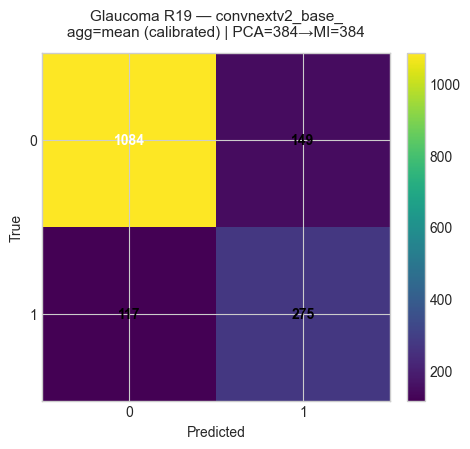

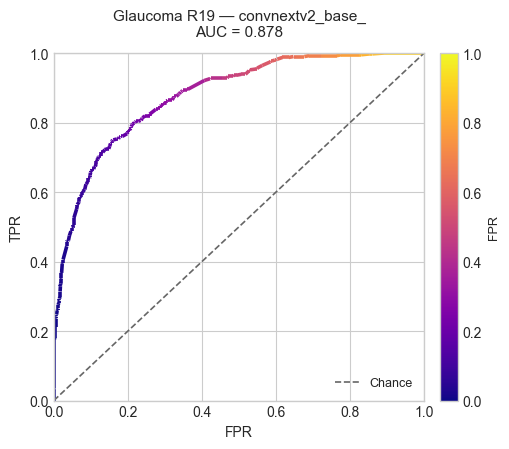


════════════════════════════════════════════════════════════════════════════════
[2/7] dinov3_convnext_base
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024-D → 384-D  (variance retained: 99.5%)
  MI Selection: 384 → 384 components (dropped 0, MI thresh=0.00000, mean MI=0.00154)
  Dim: 384 MI-PCA + 5 meta = 389 total
  Train: 11363 imgs (2233 pos, 19.7%)
  Test: 2891 imgs | Train patients: 6436 | Test patients: 1625
  [Step 2] BayesSearchCV (50 iters)...
  Best CV F1: 0.5410
  Arch: (256,) | alpha: 0.000010 | lr: 0.001674
  batch: 256 | weight: 3.41
  [Step 3] Bagging (25 sub-models)...
    Arch variants: [(256,), (384,), (256, 128), (171,), (128,)]
    Bagged 25 test proba arrays
  [Step 3b] Isotonic calibration...
    Calibrated 8551 pooled val samples
    Test proba range (cal): [0.001, 0.999]
    Test proba range (raw): [0.000, 0.999]
  [Step 4] Dual-threshold aggregation sweep on inner val patients...
    Dual threshold: sweeping BOTH r

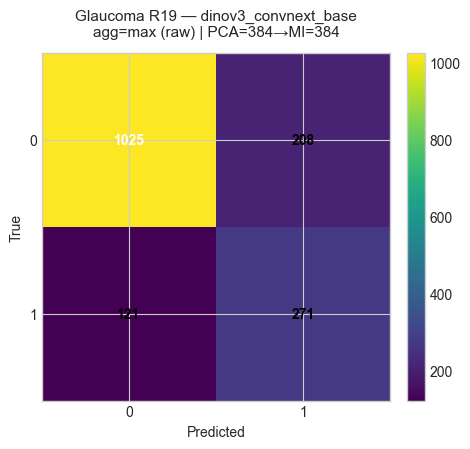

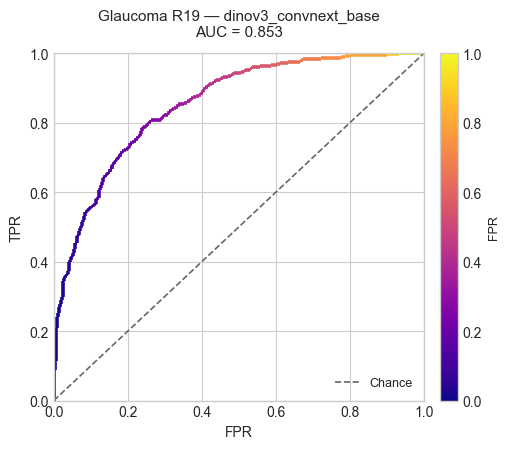


════════════════════════════════════════════════════════════════════════════════
[3/7] dinov3_vitb16
════════════════════════════════════════════════════════════════════════════════
  PCA: 768-D → 384-D  (variance retained: 98.7%)
  MI Selection: 384 → 384 components (dropped 0, MI thresh=0.00000, mean MI=0.00133)
  Dim: 384 MI-PCA + 5 meta = 389 total
  Train: 11363 imgs (2233 pos, 19.7%)
  Test: 2891 imgs | Train patients: 6436 | Test patients: 1625
  [Step 2] BayesSearchCV (50 iters)...
  Best CV F1: 0.5818
  Arch: (128,) | alpha: 0.000010 | lr: 0.010000
  batch: 256 | weight: 3.28
  [Step 3] Bagging (25 sub-models)...
    Arch variants: [(128,), (192,), (128, 64), (85,), (64,)]
    Bagged 25 test proba arrays
  [Step 3b] Isotonic calibration...
    Calibrated 8551 pooled val samples
    Test proba range (cal): [0.001, 0.999]
    Test proba range (raw): [0.000, 1.000]
  [Step 4] Dual-threshold aggregation sweep on inner val patients...
    Dual threshold: sweeping BOTH raw and cali

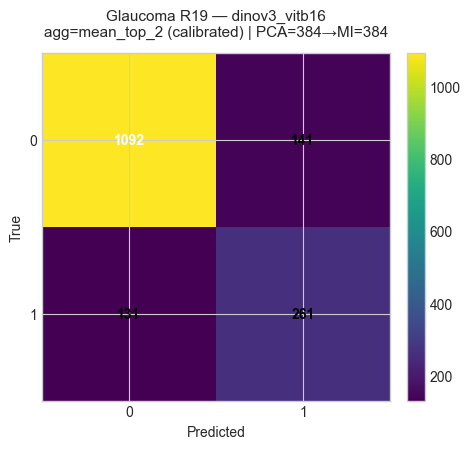

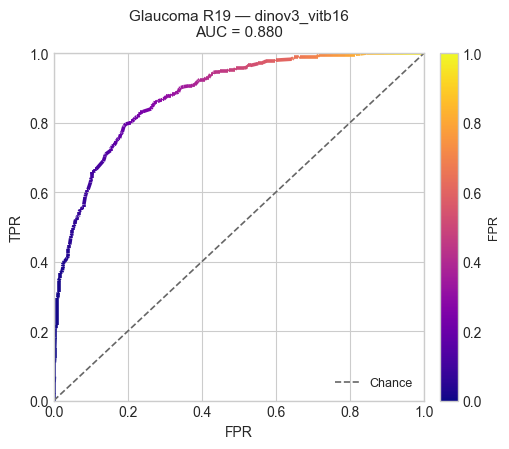


════════════════════════════════════════════════════════════════════════════════
[4/7] RETFound_dinov2_shanghai
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024-D → 384-D  (variance retained: 98.2%)
  MI Selection: 384 → 384 components (dropped 0, MI thresh=0.00000, mean MI=0.00145)
  Dim: 384 MI-PCA + 5 meta = 389 total
  Train: 11363 imgs (2233 pos, 19.7%)
  Test: 2891 imgs | Train patients: 6436 | Test patients: 1625
  [Step 2] BayesSearchCV (50 iters)...
  Best CV F1: 0.5509
  Arch: (512,) | alpha: 0.001609 | lr: 0.005414
  batch: 256 | weight: 3.23
  [Step 3] Bagging (25 sub-models)...
    Arch variants: [(512,), (768,), (512, 256), (343,), (256,)]
    Bagged 25 test proba arrays
  [Step 3b] Isotonic calibration...
    Calibrated 8551 pooled val samples
    Test proba range (cal): [0.001, 0.999]
    Test proba range (raw): [0.000, 0.999]
  [Step 4] Dual-threshold aggregation sweep on inner val patients...
    Dual threshold: sweeping BO

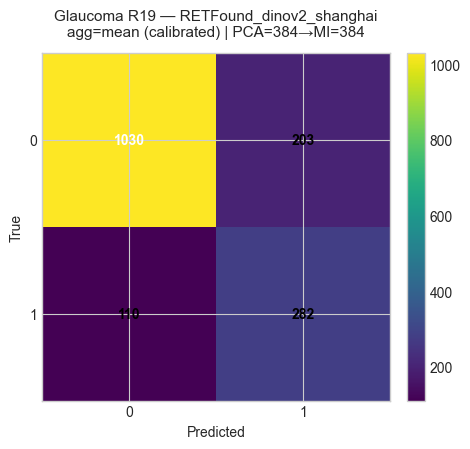

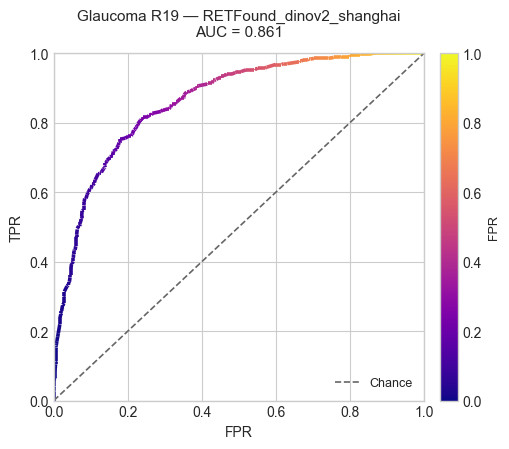


════════════════════════════════════════════════════════════════════════════════
[5/7] RETFound_mae_natureCFP
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024-D → 384-D  (variance retained: 99.3%)
  MI Selection: 384 → 384 components (dropped 0, MI thresh=0.00000, mean MI=0.00137)
  Dim: 384 MI-PCA + 5 meta = 389 total
  Train: 11363 imgs (2233 pos, 19.7%)
  Test: 2891 imgs | Train patients: 6436 | Test patients: 1625
  [Step 2] BayesSearchCV (50 iters)...
  Best CV F1: 0.5164
  Arch: (384, 192) | alpha: 0.000011 | lr: 0.003566
  batch: 256 | weight: 4.44
  [Step 3] Bagging (25 sub-models)...
    Arch variants: [(384, 192), (576, 288), (384, 192, 96), (257, 128), (384,)]
    Bagged 25 test proba arrays
  [Step 3b] Isotonic calibration...
    Calibrated 8551 pooled val samples
    Test proba range (cal): [0.001, 0.918]
    Test proba range (raw): [0.005, 0.996]
  [Step 4] Dual-threshold aggregation sweep on inner val patients...
    Dual thre

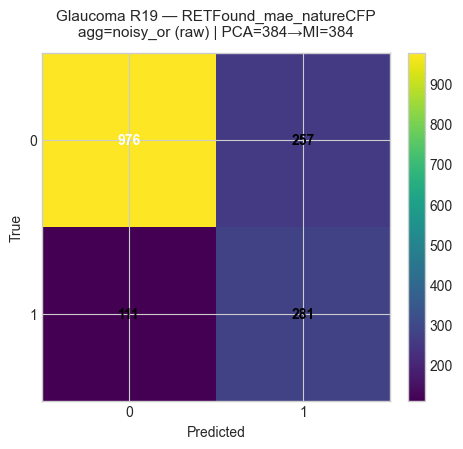

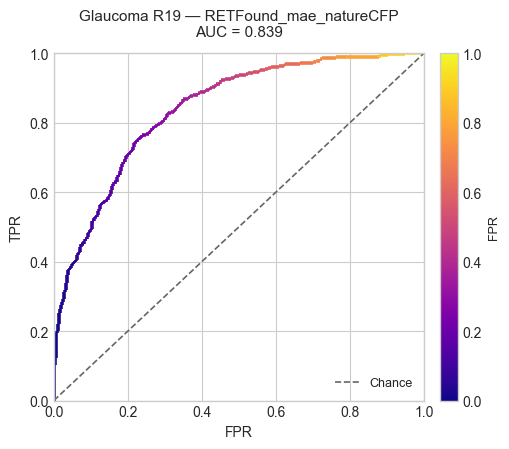


════════════════════════════════════════════════════════════════════════════════
[6/7] RETFound_mae_shanghai
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024-D → 384-D  (variance retained: 98.9%)
  MI Selection: 384 → 384 components (dropped 0, MI thresh=0.00000, mean MI=0.00136)
  Dim: 384 MI-PCA + 5 meta = 389 total
  Train: 11363 imgs (2233 pos, 19.7%)
  Test: 2891 imgs | Train patients: 6436 | Test patients: 1625
  [Step 2] BayesSearchCV (50 iters)...
  Best CV F1: 0.5202
  Arch: (128,) | alpha: 0.100000 | lr: 0.000322
  batch: 256 | weight: 3.42
  [Step 3] Bagging (25 sub-models)...
    Arch variants: [(128,), (192,), (128, 64), (85,), (64,)]
    Bagged 25 test proba arrays
  [Step 3b] Isotonic calibration...
    Calibrated 8551 pooled val samples
    Test proba range (cal): [0.001, 0.864]
    Test proba range (raw): [0.002, 0.991]
  [Step 4] Dual-threshold aggregation sweep on inner val patients...
    Dual threshold: sweeping BOTH raw

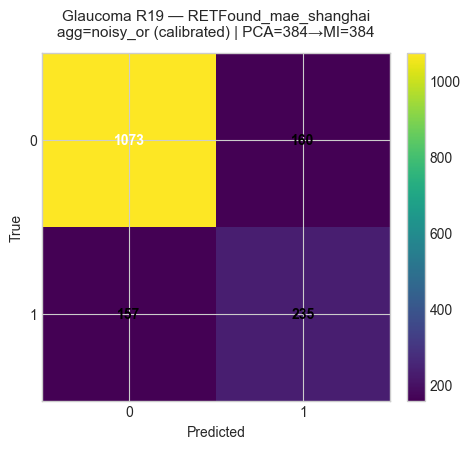

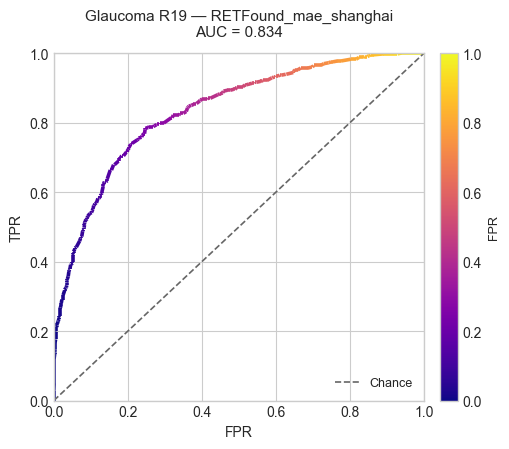


════════════════════════════════════════════════════════════════════════════════
[7/7] vit_base_
════════════════════════════════════════════════════════════════════════════════
  PCA: 768-D → 384-D  (variance retained: 98.9%)
  MI Selection: 384 → 384 components (dropped 0, MI thresh=0.00000, mean MI=0.00141)
  Dim: 384 MI-PCA + 5 meta = 389 total
  Train: 11363 imgs (2233 pos, 19.7%)
  Test: 2891 imgs | Train patients: 6436 | Test patients: 1625
  [Step 2] BayesSearchCV (50 iters)...
  Best CV F1: 0.5283
  Arch: (384, 192) | alpha: 0.066361 | lr: 0.000177
  batch: 256 | weight: 4.43
  [Step 3] Bagging (25 sub-models)...
    Arch variants: [(384, 192), (576, 288), (384, 192, 96), (257, 128), (384,)]
    Bagged 25 test proba arrays
  [Step 3b] Isotonic calibration...
    Calibrated 8551 pooled val samples
    Test proba range (cal): [0.001, 0.999]
    Test proba range (raw): [0.000, 0.996]
  [Step 4] Dual-threshold aggregation sweep on inner val patients...
    Dual threshold: sweepin

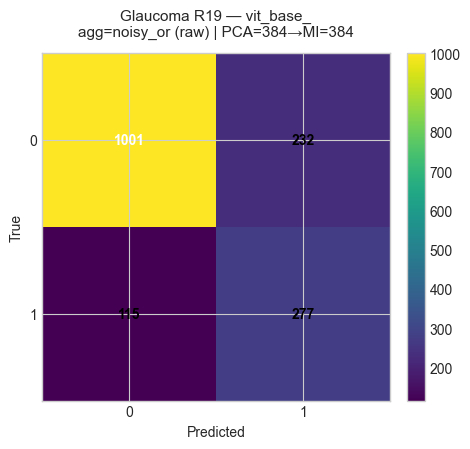

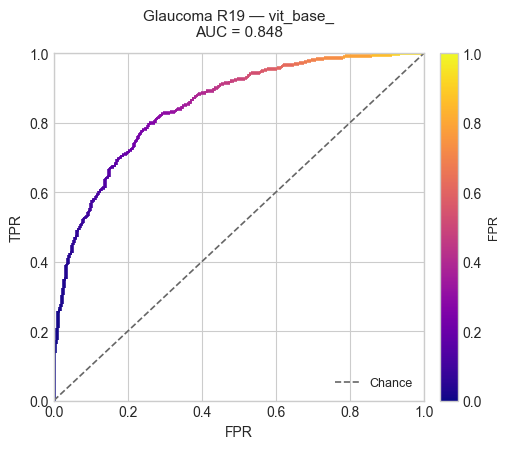


════════════════════════════════════════════════════════════════════════════════
R19 complete! Total: 7963s (132.7 min)
════════════════════════════════════════════════════════════════════════════════


In [10]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 5 — Main R19 MLP Loop (PCA-384 + MI selection + dual threshold)
# ═══════════════════════════════════════════════════════════════════════

all_results = []
t0_total = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] {sname}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ── Load & split ───────────────────────────────────────────────
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)
    train_df = df[df['patient_id'].isin(train_patient_ids)].dropna(subset=[TASK]).copy()
    test_df  = df[df['patient_id'].isin(test_patient_ids)].dropna(subset=[TASK]).copy()

    # Embedding features
    X_train_emb = train_df[ds.feature_cols].to_numpy(dtype=np.float32)
    y_train = train_df[TASK].to_numpy(dtype=int)
    pids_train = train_df['patient_id'].to_numpy()

    X_test_emb = test_df[ds.feature_cols].to_numpy(dtype=np.float32)
    y_test = test_df[TASK].to_numpy(dtype=int)
    pids_test = test_df['patient_id'].to_numpy()

    emb_dim_raw = X_train_emb.shape[1]

    # ── Step 1a: PCA dimensionality reduction ─────────────────────
    n_components = min(PCA_COMPONENTS, emb_dim_raw, X_train_emb.shape[0])
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train_emb)
    X_test_pca  = pca.transform(X_test_emb)
    var_explained = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}-D → {n_components}-D  (variance retained: {var_explained:.1%})')

    # ── Step 1b: MI Feature Selection (R19 NEW) ───────────────────
    if MI_SELECTION:
        X_train_pca_sel, X_test_pca_sel, mi_mask, mi_scores = mi_select_features(
            X_train_pca, y_train, X_test_pca,
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        n_dropped = len(mi_mask) - n_kept
        mi_mean = mi_scores.mean()
        mi_thresh_val = np.percentile(mi_scores, MI_PERCENTILE_THRESH * 100)
        print(f'  MI Selection: {n_components} → {n_kept} components '
              f'(dropped {n_dropped}, MI thresh={mi_thresh_val:.5f}, mean MI={mi_mean:.5f})')
    else:
        X_train_pca_sel = X_train_pca
        X_test_pca_sel  = X_test_pca
        mi_mask = np.ones(n_components, dtype=bool)
        mi_scores = np.zeros(n_components)
        n_kept = n_components

    # Clinical metadata (fit stats from train, apply to test)
    X_train_meta, meta_stats = encode_metadata(train_df, METADATA_COLS)
    X_test_meta, _ = encode_metadata(test_df, METADATA_COLS, fit_stats=meta_stats)

    # Concatenate: [MI-selected PCA | metadata]
    X_train = np.hstack([X_train_pca_sel, X_train_meta])
    X_test  = np.hstack([X_test_pca_sel, X_test_meta])

    emb_dim = X_train_pca_sel.shape[1]
    meta_dim = X_train_meta.shape[1]
    ndim = X_train.shape[1]
    pos_rate = y_train.mean()
    print(f'  Dim: {emb_dim} MI-PCA + {meta_dim} meta = {ndim} total')
    print(f'  Train: {len(y_train)} imgs ({y_train.sum()} pos, {pos_rate:.1%})')
    print(f'  Test: {len(y_test)} imgs | Train patients: {len(set(pids_train))} | Test patients: {len(set(pids_test))}')

    # Scale (applied AFTER PCA + MI selection)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # ── Step 2: BayesSearchCV ──────────────────────────────────────
    print(f'  [Step 2] BayesSearchCV ({BAYES_N_ITER} iters)...')
    base_mlp = MLPWrapperForBayesSearch(
        max_iter=MLP_MAX_ITER, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
        random_state=RANDOM_SEED,
    )
    bayes = BayesSearchCV(
        estimator=base_mlp, search_spaces=SEARCH_SPACE,
        n_iter=BAYES_N_ITER, cv=BAYES_CV_FOLDS,
        n_jobs=BAYES_N_JOBS, scoring='f1',
        random_state=RANDOM_SEED, verbose=0,
    )
    bayes.fit(X_train_s, y_train)

    bp = bayes.best_params_
    best_cv_f1 = bayes.best_score_
    arch_idx = bp.get('hidden_layer_sizes', 0)
    best_arch = ARCHITECTURE_OPTIONS[arch_idx] if isinstance(arch_idx, int) else arch_idx
    best_alpha = bp['alpha']
    best_lr = bp['learning_rate_init']
    best_bs = bp['batch_size']
    best_weight = bp['pos_class_weight']

    print(f'  Best CV F1: {best_cv_f1:.4f}')
    print(f'  Arch: {best_arch} | alpha: {best_alpha:.6f} | lr: {best_lr:.6f}')
    print(f'  batch: {best_bs} | weight: {best_weight:.2f}')

    # ── Step 3: Heavy Bagging (25 sub-models) ──────────────────────
    print(f'  [Step 3] Bagging ({N_BAGS} sub-models)...')

    # Resolve 5 arch variants from best
    archs = [
        best_arch,                  # original best
        make_wider(best_arch),      # 1.5× wider
        make_deeper(best_arch),     # +1 layer
        make_narrower(best_arch),   # 0.67× narrower
        make_shallower(best_arch),  # remove last layer
    ]
    print(f'    Arch variants: {archs}')

    # Collect val probas from ALL seeds for better calibration
    all_bag_val_probas = []     # list of arrays, one per sub-model (first seed)
    all_bag_val_pids   = None
    all_bag_val_labels = None
    bag_test_probas = []

    # For calibration: collect val probas from ALL seeds
    calib_val_probas_per_seed = {}
    calib_val_pids_per_seed   = {}
    calib_val_labels_per_seed = {}

    for s_idx, seed in enumerate(BAG_SEEDS):
        # Patient-level inner split for this seed
        unique_tr_pids = np.unique(pids_train)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        pid_label_map = train_df.groupby('patient_id')[TASK].max().to_dict()
        pid_labels = np.array([pid_label_map[p] for p in unique_tr_pids])
        inner_tr_idx, inner_va_idx = next(sss.split(unique_tr_pids, pid_labels))
        inner_tr_pids = set(unique_tr_pids[inner_tr_idx])
        inner_va_pids = set(unique_tr_pids[inner_va_idx])

        tr_mask = np.isin(pids_train, list(inner_tr_pids))
        va_mask = np.isin(pids_train, list(inner_va_pids))

        X_inner_tr = X_train_s[tr_mask]
        y_inner_tr = y_train[tr_mask]
        X_inner_va = X_train_s[va_mask]
        y_inner_va = y_train[va_mask]
        pids_inner_va = pids_train[va_mask]

        seed_val_probas = []

        for a_idx, arch in enumerate(archs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch, alpha=best_alpha,
                learning_rate_init=best_lr, batch_size=best_bs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_inner_tr, best_weight)
            mlp.fit(X_inner_tr, y_inner_tr, sample_weight=sw)

            va_proba = mlp.predict_proba(X_inner_va)[:, 1]
            seed_val_probas.append(va_proba)

            # Use first seed's val set for aggregation sweep
            if s_idx == 0:
                all_bag_val_probas.append(va_proba)
                if a_idx == 0:
                    all_bag_val_pids = pids_inner_va
                    all_bag_val_labels = y_inner_va

            # Test probas (all 25 sub-models)
            bag_test_probas.append(mlp.predict_proba(X_test_s)[:, 1])

        # Store per-seed val data for calibration
        calib_val_probas_per_seed[seed] = np.mean(seed_val_probas, axis=0)
        calib_val_pids_per_seed[seed]   = pids_inner_va
        calib_val_labels_per_seed[seed] = y_inner_va

    # Average bagged image-level probas
    avg_test_proba_raw = np.mean(bag_test_probas, axis=0)
    avg_val_proba_raw  = np.mean(all_bag_val_probas, axis=0)

    print(f'    Bagged {len(bag_test_probas)} test proba arrays')

    # ── Step 3b: Isotonic Calibration ──────────────────────────────
    if CALIBRATE:
        print(f'  [Step 3b] Isotonic calibration...')
        calib_probas_all = []
        calib_labels_all = []
        for seed in BAG_SEEDS:
            calib_probas_all.append(calib_val_probas_per_seed[seed])
            calib_labels_all.append(calib_val_labels_per_seed[seed])
        calib_probas_pooled = np.concatenate(calib_probas_all)
        calib_labels_pooled = np.concatenate(calib_labels_all)

        iso_reg = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
        iso_reg.fit(calib_probas_pooled, calib_labels_pooled)

        avg_test_proba_cal = iso_reg.predict(avg_test_proba_raw)
        avg_val_proba_cal  = iso_reg.predict(avg_val_proba_raw)
        print(f'    Calibrated {len(calib_probas_pooled)} pooled val samples')
        print(f'    Test proba range (cal): [{avg_test_proba_cal.min():.3f}, {avg_test_proba_cal.max():.3f}]')
        print(f'    Test proba range (raw): [{avg_test_proba_raw.min():.3f}, {avg_test_proba_raw.max():.3f}]')
    else:
        avg_test_proba_cal = avg_test_proba_raw
        avg_val_proba_cal  = avg_val_proba_raw

    # ── Step 4: Dual-Threshold Aggregation Sweep (R19 NEW) ─────────
    #   Sweep agg × threshold on BOTH raw and calibrated probas,
    #   then pick whichever (proba_type, agg, threshold) gives best val F1
    print(f'  [Step 4] Dual-threshold aggregation sweep on inner val patients...')

    pat_labels_val = aggregate_patient_labels(all_bag_val_pids, all_bag_val_labels)

    best_agg = 'mean'
    best_agg_f1 = 0.0
    best_agg_thresh = 0.5
    best_proba_type = 'calibrated'

    # Define which proba streams to try
    proba_streams = {'calibrated': (avg_val_proba_cal, avg_test_proba_cal)}
    if DUAL_THRESHOLD and CALIBRATE:
        proba_streams['raw'] = (avg_val_proba_raw, avg_test_proba_raw)
        print(f'    Dual threshold: sweeping BOTH raw and calibrated probas')

    for proba_type, (val_proba_stream, _) in proba_streams.items():
        for agg in AGG_METHODS:
            pat_proba_val = aggregate_patient_proba(all_bag_val_pids, val_proba_stream, method=agg)
            common_pids = pat_proba_val.index.intersection(pat_labels_val.index)
            y_true_agg = pat_labels_val.loc[common_pids].values
            y_proba_agg = pat_proba_val.loc[common_pids].values

            thresh, f1_val = find_optimal_threshold(y_true_agg, y_proba_agg,
                                                    grid_size=THRESHOLD_GRID_SIZE,
                                                    floor=THRESHOLD_FLOOR)
            tag = f'[{proba_type:>4}]'
            print(f'    {tag} {agg:>14}: val F1={f1_val:.4f}  thresh={thresh:.3f}')
            if f1_val > best_agg_f1:
                best_agg_f1 = f1_val
                best_agg = agg
                best_agg_thresh = thresh
                best_proba_type = proba_type

    print(f'  ★ Best: {best_proba_type} + {best_agg} (val F1={best_agg_f1:.4f}, thresh={best_agg_thresh:.3f})')

    # Select the winning proba stream for test evaluation
    if best_proba_type == 'raw':
        avg_test_proba_final = avg_test_proba_raw
    else:
        avg_test_proba_final = avg_test_proba_cal

    # ── Step 5: Evaluate on test patients ──────────────────────────
    print(f'  [Step 5] Test evaluation...')

    pat_labels_test = aggregate_patient_labels(pids_test, y_test)
    pat_proba_test = aggregate_patient_proba(pids_test, avg_test_proba_final, method=best_agg)

    common_test = pat_proba_test.index.intersection(pat_labels_test.index)
    y_true_test = pat_labels_test.loc[common_test].values
    y_proba_test = pat_proba_test.loc[common_test].values
    y_pred_test = (y_proba_test >= best_agg_thresh).astype(int)

    f1  = f1_score(y_true_test, y_pred_test, zero_division=0)
    prec = precision_score(y_true_test, y_pred_test, zero_division=0)
    rec  = recall_score(y_true_test, y_pred_test, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true_test, y_pred_test)
    auc_val = roc_auc_score(y_true_test, y_proba_test)
    fpr, tpr, _ = roc_curve(y_true_test, y_proba_test)

    elapsed = time.time() - t0
    print(f'\n  ┌─── Patient-Level Results ({sname}) ───')
    print(f'  │ PCA:              {emb_dim_raw}-D → {n_components}-D ({var_explained:.1%} var)')
    print(f'  │ MI Selection:     {n_components} → {n_kept} components')
    print(f'  │ Calibration:      {"Isotonic" if CALIBRATE else "None"}')
    print(f'  │ Proba type:       {best_proba_type}')
    print(f'  │ Agg method:       {best_agg}')
    print(f'  │ Threshold:        {best_agg_thresh:.3f}')
    print(f'  │ F1 Score:         {f1:.3f}')
    print(f'  │ Precision:        {prec:.3f}')
    print(f'  │ Recall:           {rec:.3f}')
    print(f'  │ ROC AUC:          {auc_val:.3f}')
    print(f'  │ Balanced Acc:     {bal_acc:.3f}')
    print(f'  │ Test patients:    {len(common_test)}')
    print(f'  │ N bags:           {len(bag_test_probas)}')
    print(f'  │ Time:             {elapsed:.0f}s')
    print(f'  └───────────────────────────────────────')

    report = classification_report(y_true_test, y_pred_test, digits=3)
    print(report)

    cm = confusion_matrix(y_true_test, y_pred_test)

    # ── Save per-embedding ─────────────────────────────────────────
    out_dir = RESULTS_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    (out_dir / 'classification_report.txt').write_text(report, encoding='utf-8')
    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)

    hp_save = {
        'architecture_best': str(best_arch),
        'arch_variants': [str(a) for a in archs],
        'alpha': float(best_alpha), 'lr': float(best_lr),
        'batch_size': int(best_bs), 'pos_class_weight': float(best_weight),
        'n_bags': N_BAGS, 'best_agg': best_agg,
        'threshold': float(best_agg_thresh),
        'best_cv_f1': float(best_cv_f1),
        'proba_type': best_proba_type,
        'dual_threshold': DUAL_THRESHOLD,
        'metadata_cols': list(METADATA_COLS.keys()),
        'emb_dim_raw': emb_dim_raw, 'pca_dim': n_components,
        'mi_selected_dim': int(n_kept),
        'mi_selection': MI_SELECTION,
        'pca_var_explained': float(var_explained),
        'meta_dim': meta_dim, 'total_dim': ndim,
        'calibration': 'isotonic' if CALIBRATE else 'none',
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    # Save MI scores for analysis
    if MI_SELECTION:
        pd.DataFrame({
            'pca_component': range(len(mi_scores)),
            'mi_score': mi_scores,
            'selected': mi_mask,
        }).to_csv(out_dir / 'mi_scores.csv', index=False)

    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)
    pd.DataFrame({
        'patient_id': common_test, 'y_true': y_true_test,
        'y_pred': y_pred_test, 'y_proba': y_proba_test,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    plot_confusion_matrix(cm,
        title=f'Glaucoma R19 — {sname}\nagg={best_agg} ({best_proba_type}) | PCA={n_components}→MI={n_kept}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, auc_val,
        title=f'Glaucoma R19 — {sname}',
        save_path=out_dir / 'roc_curve.png', show=True)

    # Also evaluate ALL agg methods on test (for comparison table)
    agg_test_results = {}
    for agg in AGG_METHODS:
        pp = aggregate_patient_proba(pids_test, avg_test_proba_final, method=agg)
        common = pp.index.intersection(pat_labels_test.index)
        yt = pat_labels_test.loc[common].values
        yp = pp.loc[common].values
        t_opt, f1_opt = find_optimal_threshold(yt, yp, grid_size=THRESHOLD_GRID_SIZE, floor=THRESHOLD_FLOOR)
        agg_test_results[agg] = {'f1': f1_opt, 'thresh': t_opt, 'auc': roc_auc_score(yt, yp)}

    all_results.append({
        'embedding': sname,
        'dim_raw': emb_dim_raw,
        'dim_pca': n_components,
        'dim_mi_selected': int(n_kept),
        'pca_var': float(var_explained),
        'dim_total': ndim,
        'best_arch': str(best_arch),
        'pos_class_weight': float(best_weight),
        'best_cv_f1': float(best_cv_f1),
        'n_bags': len(bag_test_probas),
        'calibrated': CALIBRATE,
        'proba_type': best_proba_type,
        'best_agg': best_agg,
        'threshold': float(best_agg_thresh),
        'f1_score': float(f1),
        'precision': float(prec),
        'recall': float(rec),
        'auc': float(auc_val),
        'balanced_accuracy': float(bal_acc),
        'n_test_patients': len(common_test),
        'time_s': float(elapsed),
        # All agg methods on test set (oracle)
        **{f'test_f1_{agg}': agg_test_results[agg]['f1'] for agg in AGG_METHODS},
    })

total_time = time.time() - t0_total
print(f'\n{"═"*80}')
print(f'R19 complete! Total: {total_time:.0f}s ({total_time/60:.1f} min)')
print(f'{"═"*80}')

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 6 — Summary and Cross-Phase Comparison (R19)
# ═══════════════════════════════════════════════════════════════════════

r19_df = pd.DataFrame(all_results).sort_values('f1_score', ascending=False)
r19_df.to_csv(RESULTS_DIR / 'r19_summary.csv', index=False)

print('=' * 110)
print('R19 RESULTS — PCA-384 + MI Selection + Dual Threshold + 50-iter BayesSearch (Cleaned BRSET)')
print('=' * 110)
display(r19_df[['embedding', 'dim_raw', 'dim_pca', 'dim_mi_selected', 'pca_var', 'best_arch',
                'pos_class_weight', 'proba_type', 'best_agg', 'threshold',
                'f1_score', 'precision', 'recall', 'auc', 'balanced_accuracy']])

# ─── All agg methods on test ───
print('\nTest F1 by aggregation method (oracle, per embedding):')
agg_cols = [f'test_f1_{agg}' for agg in AGG_METHODS]
header = f'{"Embedding":<30}' + ''.join(f' {agg:>13}' for agg in AGG_METHODS)
print(header)
print('-' * len(header))
for _, row in r19_df.iterrows():
    vals = ''.join(f' {row[f"test_f1_{agg}"]:>12.3f}' for agg in AGG_METHODS)
    print(f'  {row["embedding"]:<28}{vals}')

# ─── Comparison with P1/P2/R17/R18 ───
try:
    p1_df = pd.read_csv(ORIG_P1_CSV); has_p1 = True
except FileNotFoundError:
    p1_df = pd.DataFrame(); has_p1 = False

try:
    p2_df = pd.read_csv(ORIG_P2_CSV); has_p2 = True
except FileNotFoundError:
    p2_df = pd.DataFrame(); has_p2 = False

try:
    r17_df_prev = pd.read_csv(ORIG_R17_CSV); has_r17 = True
except FileNotFoundError:
    r17_df_prev = pd.DataFrame(); has_r17 = False

try:
    r18_df_prev = pd.read_csv(ORIG_R18_CSV); has_r18 = True
except FileNotFoundError:
    r18_df_prev = pd.DataFrame(); has_r18 = False

print('\n' + '=' * 130)
print('CROSS-PHASE COMPARISON (best F1 per embedding)')
print('  P1 = Phase 1 | P2 = Phase 2 | R17 = R17-MLP | R18 = R18-Turbo | R19 = This run (PCA-384 + MI + dual threshold)')
print('=' * 130)
print(f'{"Embedding":<28} {"P1":>6} {"P2":>6} {"R17":>6} {"R18":>6} {"R19":>6} {"Best":>6}  {"Δ(R19-R18)":>11}')
print('-' * 130)

comp_rows = []
for _, row in r19_df.iterrows():
    emb = row['embedding']
    r19_f1 = row['f1_score']
    r19_auc = row['auc']

    p1_f1 = 0
    if has_p1:
        m = p1_df[p1_df['embedding'].str.contains(emb.replace('_',''), case=False)]
        p1_f1 = m['f1_score'].max() if not m.empty else 0

    p2_f1 = 0
    if has_p2:
        m = p2_df[p2_df['embedding'] == emb]
        p2_f1 = m['f1_score'].max() if not m.empty else 0

    r17_f1 = 0
    if has_r17:
        m = r17_df_prev[r17_df_prev['embedding'] == emb]
        r17_f1 = m['f1_score'].max() if not m.empty else 0

    r18_f1 = 0
    if has_r18:
        m = r18_df_prev[r18_df_prev['embedding'] == emb]
        r18_f1 = m['f1_score'].max() if not m.empty else 0

    prev_best = max(p1_f1, p2_f1, r17_f1, r18_f1)
    overall_best = max(prev_best, r19_f1)
    phases = {'P1': p1_f1, 'P2': p2_f1, 'R17': r17_f1, 'R18': r18_f1, 'R19': r19_f1}
    best_phase = max(phases, key=phases.get)
    delta_r18 = r19_f1 - r18_f1 if r18_f1 > 0 else float('nan')

    print(f'  {emb:<26} {p1_f1:>5.3f}  {p2_f1:>5.3f}  {r17_f1:>5.3f}  {r18_f1:>5.3f}  {r19_f1:>5.3f}  '
          f'{overall_best:>5.3f}({best_phase:>3})  {delta_r18:>+10.3f}')

    comp_rows.append({
        'embedding': emb, 'phase1_f1': p1_f1, 'phase2_f1': p2_f1,
        'r17_mlp_f1': r17_f1, 'r18_turbo_f1': r18_f1,
        'r19_f1': r19_f1, 'r19_auc': r19_auc,
        'best_f1': overall_best, 'best_phase': best_phase, 'delta_r18': delta_r18,
    })

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(RESULTS_DIR / 'cross_phase_comparison.csv', index=False)

best = r19_df.iloc[0]
print(f'\n★ BEST: {best["embedding"]}  F1={best["f1_score"]:.3f}  AUC={best["auc"]:.3f}  '
      f'agg={best["best_agg"]} ({best["proba_type"]})  w={best["pos_class_weight"]:.2f}  '
      f'MI-PCA={best["dim_mi_selected"]}')
print(f'Saved: {RESULTS_DIR / "r19_summary.csv"}')

R19 RESULTS — PCA-384 + MI Selection + Dual Threshold + 50-iter BayesSearch (Cleaned BRSET)


,embedding,dim_raw,dim_pca,dim_mi_selected,pca_var,best_arch,pos_class_weight,proba_type,best_agg,threshold,f1_score,precision,recall,auc,balanced_accuracy
0,convnextv2_base_,1024,384,384,0.988227,"(512,)",3.185812,calibrated,mean,0.272467,0.674020,0.648585,0.701531,0.877631,0.790344
2,dinov3_vitb16,768,384,384,0.986891,"(128,)",3.277637,calibrated,mean_top_2,0.281867,0.657431,0.649254,0.665816,0.880083,0.775731
3,RETFound_dinov2_shanghai,1024,384,384,0.981932,"(512,)",3.225461,calibrated,mean,0.250533,0.643101,0.581443,0.719388,0.861240,0.777374
1,dinov3_convnext_base,1024,384,384,0.994572,"(256,)",3.410933,raw,max,0.557600,0.622273,0.565762,0.691327,0.852678,0.761316
6,vit_base_,768,384,384,0.988988,"(384, 192)",4.429583,raw,noisy_or,0.661000,0.614872,0.544204,0.706633,0.847601,0.759237
4,RETFound_mae_natureCFP,1024,384,384,0.993334,"(384, 192)",4.436220,raw,noisy_or,0.720533,0.604301,0.522305,0.716837,0.838601,0.754201
5,RETFound_mae_shanghai,1024,384,384,0.989052,"(128,)",3.423592,calibrated,noisy_or,0.460467,0.597205,0.594937,0.599490,0.834132,0.734862



Test F1 by aggregation method (oracle, per embedding):
Embedding                               mean           max      noisy_or    mean_top_2    mean_top_3  trimmed_mean
------------------------------------------------------------------------------------------------------------------
  convnextv2_base_                    0.676        0.670        0.667        0.676        0.676        0.676
  dinov3_vitb16                       0.663        0.656        0.665        0.663        0.663        0.663
  RETFound_dinov2_shanghai            0.648        0.640        0.646        0.648        0.648        0.648
  dinov3_convnext_base                0.640        0.625        0.642        0.642        0.640        0.640
  vit_base_                           0.617        0.630        0.622        0.617        0.617        0.617
  RETFound_mae_natureCFP              0.599        0.608        0.612        0.600        0.599        0.600
  RETFound_mae_shanghai               0.609        0.599    

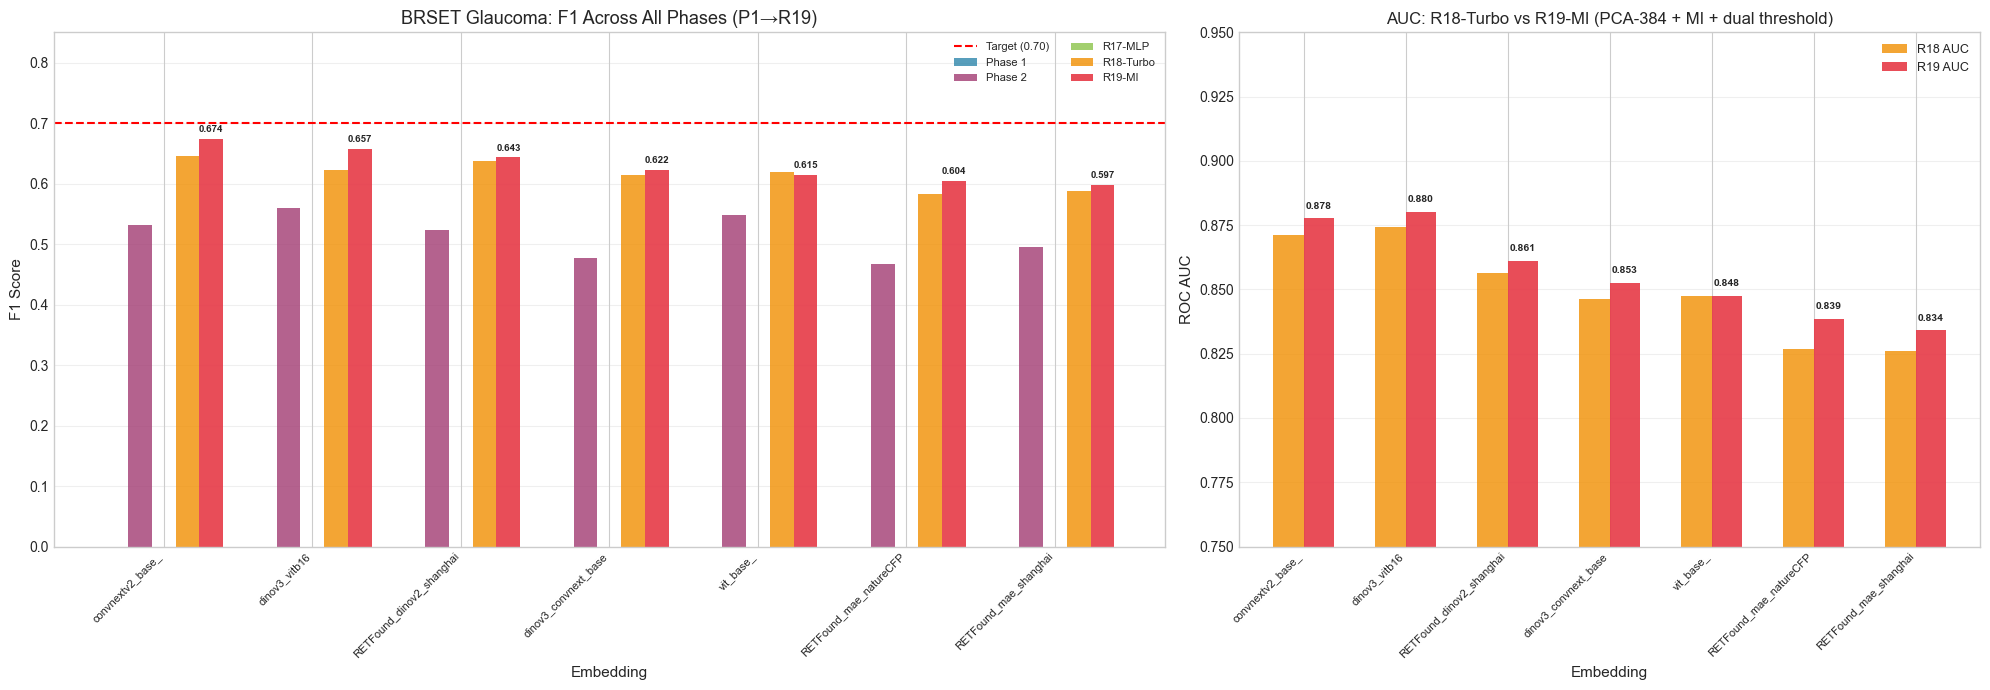

Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_glaucoma_r19_mlp\r19_comparison.png


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 7 — Bar Chart Comparison (P1/P2/R17/R18/R19)
# ═══════════════════════════════════════════════════════════════════════

embeddings_sorted = r19_df.sort_values('f1_score', ascending=False)['embedding'].tolist()
x = np.arange(len(embeddings_sorted))
width = 0.16  # narrower bars to fit 5 phases

fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={'width_ratios': [3, 2]})

# ─── Left: F1 bar chart ───
ax = axes[0]
p1_f1s, p2_f1s, r17_f1s, r18_f1s, r19_f1s = [], [], [], [], []
for emb in embeddings_sorted:
    if has_p1:
        m = p1_df[p1_df['embedding'].str.contains(emb.replace('_',''), case=False)]
        p1_f1s.append(m['f1_score'].max() if not m.empty else 0)
    else:
        p1_f1s.append(0)
    if has_p2:
        m = p2_df[p2_df['embedding'] == emb]
        p2_f1s.append(m['f1_score'].max() if not m.empty else 0)
    else:
        p2_f1s.append(0)
    if has_r17:
        m = r17_df_prev[r17_df_prev['embedding'] == emb]
        r17_f1s.append(m['f1_score'].max() if not m.empty else 0)
    else:
        r17_f1s.append(0)
    if has_r18:
        m = r18_df_prev[r18_df_prev['embedding'] == emb]
        r18_f1s.append(m['f1_score'].max() if not m.empty else 0)
    else:
        r18_f1s.append(0)
    r19_f1s.append(r19_df[r19_df['embedding'] == emb]['f1_score'].values[0])

ax.bar(x - 2*width, p1_f1s, width, label='Phase 1', color='#2E86AB', alpha=0.8)
ax.bar(x - 1*width, p2_f1s, width, label='Phase 2', color='#A23B72', alpha=0.8)
ax.bar(x + 0*width, r17_f1s, width, label='R17-MLP', color='#8BC34A', alpha=0.8)
ax.bar(x + 1*width, r18_f1s, width, label='R18-Turbo', color='#F18F01', alpha=0.8)
bars5 = ax.bar(x + 2*width, r19_f1s, width, label='R19-MI', color='#E63946', alpha=0.9)
ax.axhline(y=0.70, color='red', linestyle='--', linewidth=1.5, label='Target (0.70)')

for bar, val in zip(bars5, r19_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Embedding', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('BRSET Glaucoma: F1 Across All Phases (P1→R19)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(embeddings_sorted, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(0, 0.85)
ax.grid(axis='y', alpha=0.3)

# ─── Right: AUC comparison R18 vs R19 ───
ax2 = axes[1]
r18_aucs, r19_aucs = [], []
for emb in embeddings_sorted:
    if has_r18:
        m = r18_df_prev[r18_df_prev['embedding'] == emb]
        r18_aucs.append(m['auc'].max() if not m.empty else 0)
    else:
        r18_aucs.append(0)
    r19_aucs.append(r19_df[r19_df['embedding'] == emb]['auc'].values[0])

x2 = np.arange(len(embeddings_sorted))
ax2.bar(x2 - 0.15, r18_aucs, 0.3, label='R18 AUC', color='#F18F01', alpha=0.8)
bars_auc = ax2.bar(x2 + 0.15, r19_aucs, 0.3, label='R19 AUC', color='#E63946', alpha=0.9)

for bar, val in zip(bars_auc, r19_aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax2.set_xlabel('Embedding', fontsize=11)
ax2.set_ylabel('ROC AUC', fontsize=11)
ax2.set_title('AUC: R18-Turbo vs R19-MI (PCA-384 + MI + dual threshold)', fontsize=12)
ax2.set_xticks(x2)
ax2.set_xticklabels(embeddings_sorted, rotation=45, ha='right', fontsize=8)
ax2.legend(fontsize=9)
ax2.set_ylim(0.75, 0.95)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'r19_comparison.png', dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "r19_comparison.png"}')

## Phase R27: Full Pipeline + Masked `optic_disc` — Generalization Test

**Goal**: Integrate masked `optic_disc` into the full R26 embedding pipeline and test generalization.

**Key changes from R26:**
1. **optic_disc** added as metadata: binary (0=normal, 1=abnormal) + **missingness indicator**
2. **Per-bag-seed masking**: each of the 25 sub-models sees a DIFFERENT random `optic_disc` mask → ensemble learns to work with AND without optic_disc
3. **3 test scenarios** (same trained models, different test inputs):
   - `P_MASK=0%`: optic_disc always available (best case)
   - `P_MASK=25%`: deployment simulation (matches training)
   - `P_MASK=100%`: optic_disc never available (pure embedding performance)
4. **Overfitting check**: CV F1 vs val F1 vs test F1

**Interpretation**:
- If P100 F1 ≈ R26 F1 → embeddings carry the load, optic_disc is just a bonus
- If P0 F1 >> P100 F1 → optic_disc adds real signal when available
- If CV F1 ≈ test F1 → model generalizes (not overfitting)

Same pipeline: PCA-384 → MI selection → 5+2 metadata → StandardScaler → BayesSearchCV 50 iters → 25-bag → isotonic calibration → eye-level threshold sweep.

R27 | TRAIN mask=50% (bags 35%-70%) | OD_corrupt=10% | OD_w=0.50/0.50 | TEST P25 mask=25%
Pipeline: R26 sklearn MLP + masked optic_disc + missingness indicator
Results → c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_glaucoma_r27_masked_opticdisc_robust


════════════════════════════════════════════════════════════════════════════════
[1/7] R27 — convnextv2_base_
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  Train: 13003 imgs (2539 pos, 19.5%)
  [BayesSearchCV] 50 iters, 3-fold...
  CV F1=0.6589 | arch=(128,) | lr=0.002000 | w=2.83
  [Bagging] 25 models (5 seeds × 5 variants)
    Bagged 25 test-proba arrays
  [Calibration] Isotonic...
  [Threshold] Eye-level sweep...
  ★ Best: calibrated+mean (val eye-F1=0.6814, th=0.301)

  ┌─── R27 Results (convnextv2_base_) ─────────────────────────
  │ P_MASK=50% | (128,) 

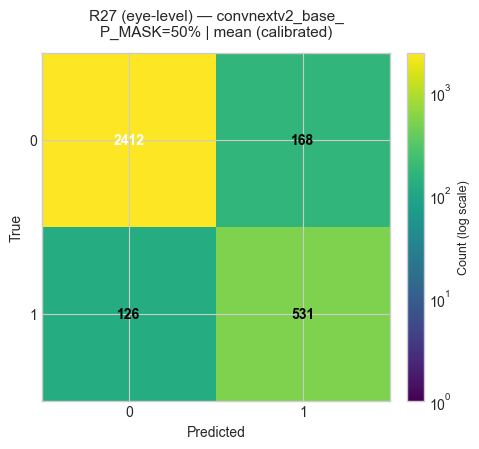

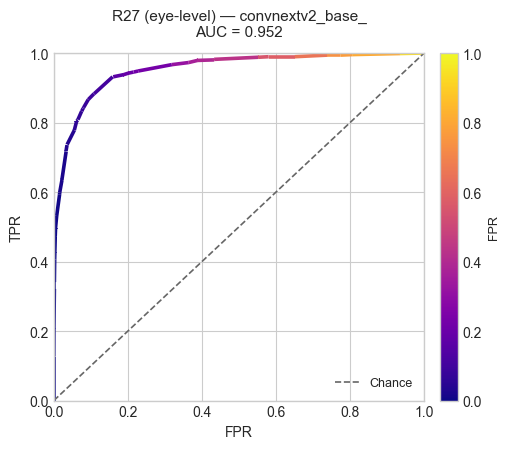


════════════════════════════════════════════════════════════════════════════════
[2/7] R27 — dinov3_convnext_base
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.4% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  Train: 13003 imgs (2539 pos, 19.5%)
  [BayesSearchCV] 50 iters, 3-fold...
  CV F1=0.6241 | arch=(256,) | lr=0.000100 | w=3.83
  [Bagging] 25 models (5 seeds × 5 variants)
    Bagged 25 test-proba arrays
  [Calibration] Isotonic...
  [Threshold] Eye-level sweep...
  ★ Best: calibrated+noisy_or (val eye-F1=0.6565, th=0.335)

  ┌─── R27 Results (dinov3_convnext_base) ─────────────────────────
  │ P_MASK=50% | (256,) | calibrated+noisy_or | th=0.335
  │
  │ OVERFITTING CHECK:
  │   CV F1 (train, 3-fold)  = 0.6241
  │   Val eye-F1 (held-out)  = 0.6565
  │   Test eye-F1 (P25)      = 0.8048
  │   Δ(CV − Test)           = -0.1807  ✓ OK
  │   Δ(Val − Test)          = -0.1483  ✓ OK
  │
  │ GENERALIZATION ACROSS optic_disc 

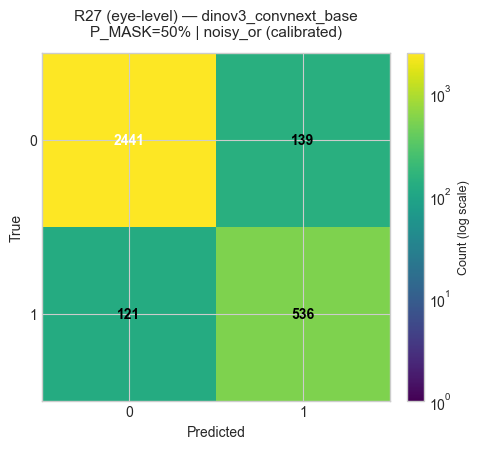

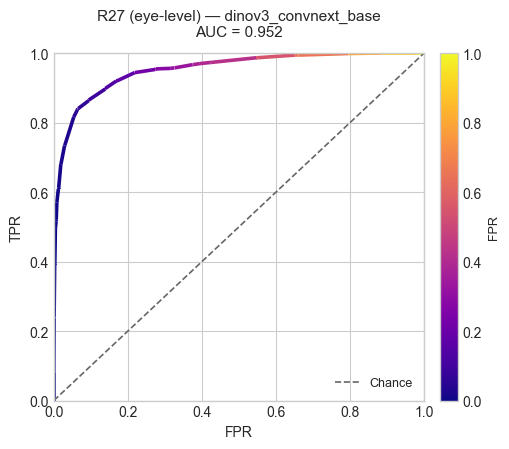


════════════════════════════════════════════════════════════════════════════════
[3/7] R27 — dinov3_vitb16
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.7% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  Train: 13003 imgs (2539 pos, 19.5%)
  [BayesSearchCV] 50 iters, 3-fold...
  CV F1=0.6644 | arch=(384, 192) | lr=0.000118 | w=2.48
  [Bagging] 25 models (5 seeds × 5 variants)
    Bagged 25 test-proba arrays
  [Calibration] Isotonic...
  [Threshold] Eye-level sweep...
  ★ Best: calibrated+noisy_or (val eye-F1=0.6925, th=0.345)

  ┌─── R27 Results (dinov3_vitb16) ─────────────────────────
  │ P_MASK=50% | (384, 192) | calibrated+noisy_or | th=0.345
  │
  │ OVERFITTING CHECK:
  │   CV F1 (train, 3-fold)  = 0.6644
  │   Val eye-F1 (held-out)  = 0.6925
  │   Test eye-F1 (P25)      = 0.7985
  │   Δ(CV − Test)           = -0.1341  ✓ OK
  │   Δ(Val − Test)          = -0.1060  ✓ OK
  │
  │ GENERALIZATION ACROSS optic_disc AVAILAB

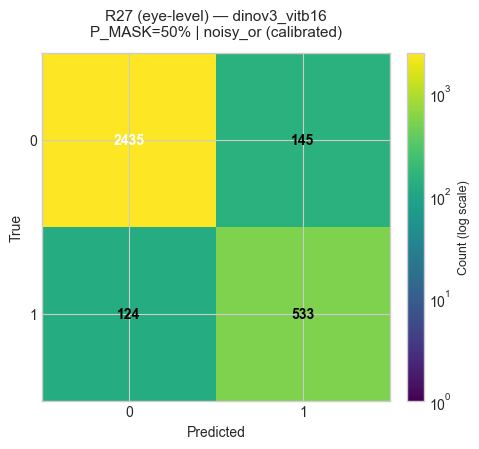

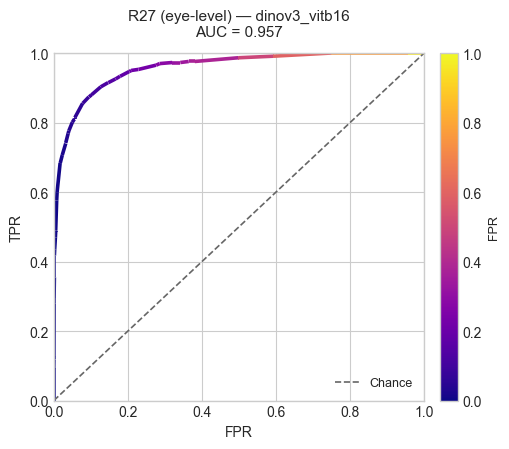


════════════════════════════════════════════════════════════════════════════════
[4/7] R27 — RETFound_dinov2_shanghai
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.1% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  Train: 13003 imgs (2539 pos, 19.5%)
  [BayesSearchCV] 50 iters, 3-fold...
  CV F1=0.6341 | arch=(128,) | lr=0.002000 | w=2.36
  [Bagging] 25 models (5 seeds × 5 variants)
    Bagged 25 test-proba arrays
  [Calibration] Isotonic...
  [Threshold] Eye-level sweep...
  ★ Best: raw+noisy_or (val eye-F1=0.6438, th=0.605)

  ┌─── R27 Results (RETFound_dinov2_shanghai) ─────────────────────────
  │ P_MASK=50% | (128,) | raw+noisy_or | th=0.605
  │
  │ OVERFITTING CHECK:
  │   CV F1 (train, 3-fold)  = 0.6341
  │   Val eye-F1 (held-out)  = 0.6438
  │   Test eye-F1 (P25)      = 0.7641
  │   Δ(CV − Test)           = -0.1300  ✓ OK
  │   Δ(Val − Test)          = -0.1203  ✓ OK
  │
  │ GENERALIZATION ACROSS optic_disc AVAILA

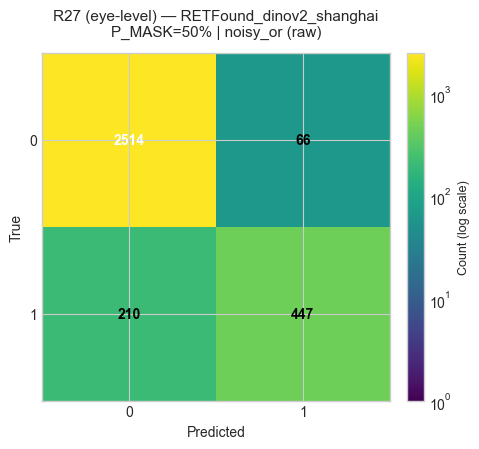

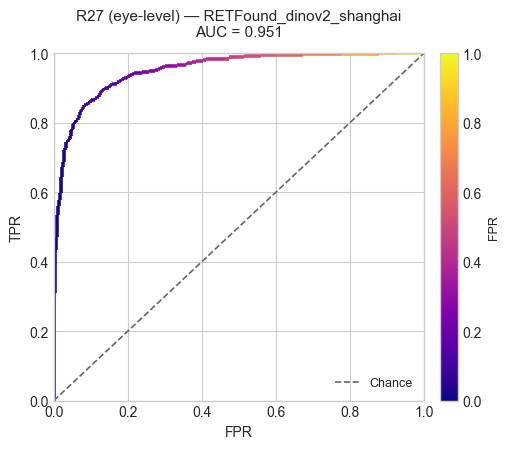


════════════════════════════════════════════════════════════════════════════════
[5/7] R27 — RETFound_mae_natureCFP
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.3% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  Train: 13003 imgs (2539 pos, 19.5%)
  [BayesSearchCV] 50 iters, 3-fold...
  CV F1=0.6050 | arch=(256,) | lr=0.002000 | w=3.57
  [Bagging] 25 models (5 seeds × 5 variants)
    Bagged 25 test-proba arrays
  [Calibration] Isotonic...
  [Threshold] Eye-level sweep...
  ★ Best: raw+noisy_or (val eye-F1=0.6266, th=0.564)

  ┌─── R27 Results (RETFound_mae_natureCFP) ─────────────────────────
  │ P_MASK=50% | (256,) | raw+noisy_or | th=0.564
  │
  │ OVERFITTING CHECK:
  │   CV F1 (train, 3-fold)  = 0.6050
  │   Val eye-F1 (held-out)  = 0.6266
  │   Test eye-F1 (P25)      = 0.7759
  │   Δ(CV − Test)           = -0.1708  ✓ OK
  │   Δ(Val − Test)          = -0.1493  ✓ OK
  │
  │ GENERALIZATION ACROSS optic_disc AVAILABILI

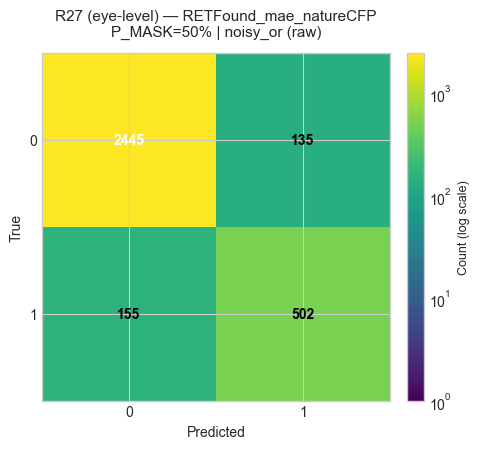

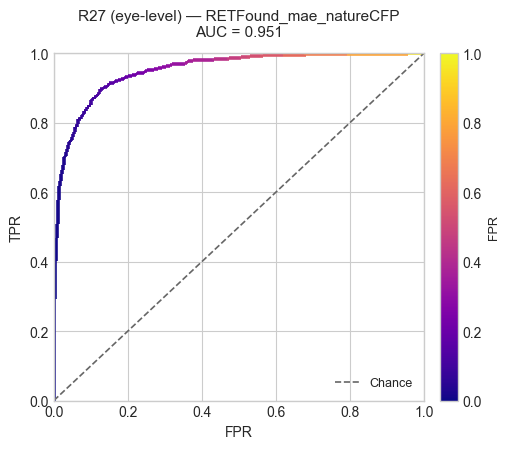


════════════════════════════════════════════════════════════════════════════════
[6/7] R27 — RETFound_mae_shanghai
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.9% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  Train: 13003 imgs (2539 pos, 19.5%)
  [BayesSearchCV] 50 iters, 3-fold...
  CV F1=0.6306 | arch=(512,) | lr=0.000100 | w=2.94
  [Bagging] 25 models (5 seeds × 5 variants)
    Bagged 25 test-proba arrays
  [Calibration] Isotonic...
  [Threshold] Eye-level sweep...
  ★ Best: raw+mean (val eye-F1=0.6519, th=0.526)

  ┌─── R27 Results (RETFound_mae_shanghai) ─────────────────────────
  │ P_MASK=50% | (512,) | raw+mean | th=0.526
  │
  │ OVERFITTING CHECK:
  │   CV F1 (train, 3-fold)  = 0.6306
  │   Val eye-F1 (held-out)  = 0.6519
  │   Test eye-F1 (P25)      = 0.7854
  │   Δ(CV − Test)           = -0.1548  ✓ OK
  │   Δ(Val − Test)          = -0.1335  ✓ OK
  │
  │ GENERALIZATION ACROSS optic_disc AVAILABILITY:
  │   

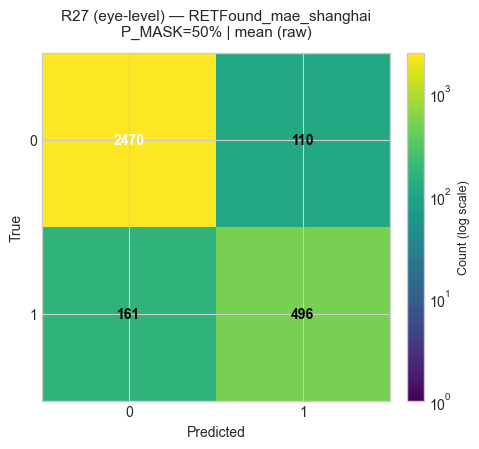

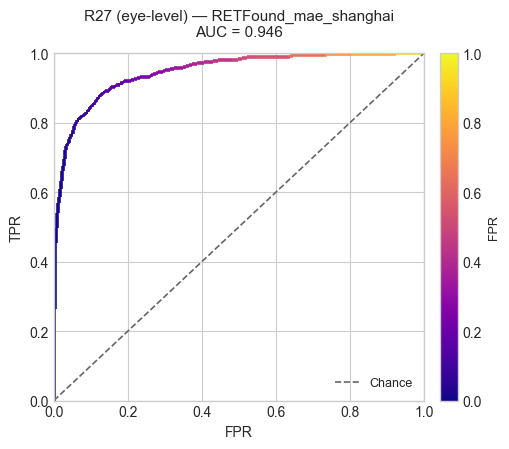


════════════════════════════════════════════════════════════════════════════════
[7/7] R27 — vit_base_
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  Train: 13003 imgs (2539 pos, 19.5%)
  [BayesSearchCV] 50 iters, 3-fold...
  CV F1=0.6332 | arch=(512,) | lr=0.000374 | w=3.01
  [Bagging] 25 models (5 seeds × 5 variants)
    Bagged 25 test-proba arrays
  [Calibration] Isotonic...
  [Threshold] Eye-level sweep...
  ★ Best: calibrated+max (val eye-F1=0.6619, th=0.260)

  ┌─── R27 Results (vit_base_) ─────────────────────────
  │ P_MASK=50% | (512,) | calibrated+max | th=0.260
  │
  │ OVERFITTING CHECK:
  │   CV F1 (train, 3-fold)  = 0.6332
  │   Val eye-F1 (held-out)  = 0.6619
  │   Test eye-F1 (P25)      = 0.7855
  │   Δ(CV − Test)           = -0.1523  ✓ OK
  │   Δ(Val − Test)          = -0.1236  ✓ OK
  │
  │ GENERALIZATION ACROSS optic_disc AVAILABILITY:
  │   P_MASK=  0%: 

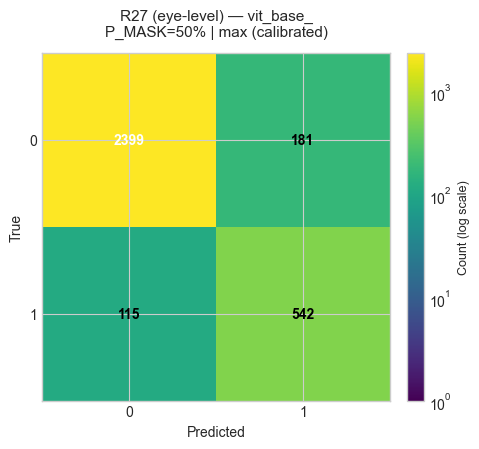

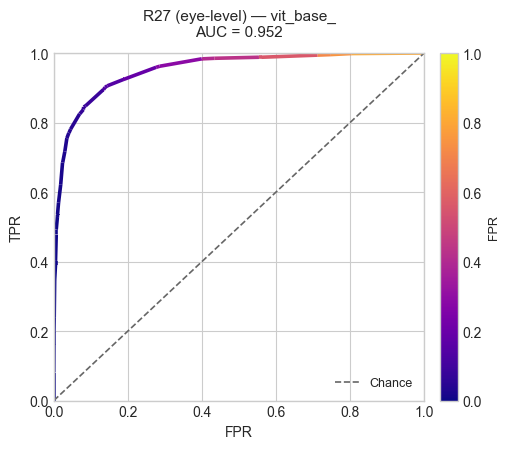


════════════════════════════════════════════════════════════════════════════════
R27 complete! Total: 18930s (315.5 min)
════════════════════════════════════════════════════════════════════════════════

── R27 Summary (sorted by P25 eye-F1) ──
               embedding    cv_f1  val_eye_f1  f1_eye_P0  f1_eye_P25  f1_eye_P100  auc_eye_P25  f1_pat_P25 best_agg
    dinov3_convnext_base 0.624083    0.656527   0.870799    0.804805     0.539608     0.952173    0.798328 noisy_or
           dinov3_vitb16 0.664414    0.692500   0.859688    0.798502     0.600772     0.957315    0.797849 noisy_or
               vit_base_ 0.633243    0.661939   0.863173    0.785507     0.571632     0.951797    0.786492      max
   RETFound_mae_shanghai 0.630647    0.651934   0.860265    0.785432     0.514630     0.945787    0.735632     mean
        convnextv2_base_ 0.658884    0.681427   0.852725    0.783186     0.596992     0.952075    0.798030     mean
  RETFound_mae_natureCFP 0.605047    0.626598   0.865031   

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Cell R27 — Full Pipeline + Masked optic_disc + Generalization Test
# ═══════════════════════════════════════════════════════════════════════
# R26 pipeline with optic_disc as a masked feature + missingness indicator.
# Per-bag-seed masking → model robust to partial availability.
# 3 test scenarios: P_MASK=0% / 25% / 100%.
# ═══════════════════════════════════════════════════════════════════════

import time, json

R27_DIR = RESULTS_DIR.parent / 'brset_glaucoma_r27_masked_opticdisc_robust'
R27_DIR.mkdir(parents=True, exist_ok=True)

# Training-time availability control (higher mask => less dependence on optic_disc)
R27_P_MASK_BASE = 0.50  # TRAIN: baseline fraction of rows where optic_disc is masked
R27_P_MASK_RANGE = (0.35, 0.70)  # TRAIN (bagging): per-seed mask-rate range; set (x,x) to disable
R27_OD_CORRUPT = 0.10  # TRAIN: flip optic_disc on 10% of unmasked rows
R27_OD_FEATURE_WEIGHT = 0.50  # post-scaler multiplier for optic_disc_masked feature
R27_OD_MISS_WEIGHT = 0.50     # post-scaler multiplier for optic_disc_missing indicator
R27_TEST_P_MASK = 0.25  # TEST: masking rate for the P25 scenario

R27_METADATA_COLS = {
    'age':      'numeric',
    'sex':      'passthrough',
    'diabetes': 'binary_yn',       # FIXED (R19 had passthrough → all zeros)
    'exam_eye': 'binary',
    'camera':   'camera',
}

# ─── Helpers ───────────────────────────────────────────────────────
def _r27_bin_od(series):
    """optic_disc: 1=normal→0, 2=abnormal→1."""
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _r27_mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    """Return (od_masked [n,1], miss_indicator [n,1])."""
    od = _r27_bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    # Optional corruption on observed optic_disc to reduce shortcut reliance
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _r27_apply_od_feature_weights(X_s, od_w, miss_w):
    """Down-weight the last two columns (od, miss) after StandardScaler.
    Modifies X_s in-place and returns it.
    """
    if X_s.shape[1] < 2:
        return X_s
    if od_w != 1.0:
        X_s[:, -2] *= od_w
    if miss_w != 1.0:
        X_s[:, -1] *= miss_w
    return X_s

print(f'R27 | TRAIN mask={R27_P_MASK_BASE:.0%} (bags {R27_P_MASK_RANGE[0]:.0%}-{R27_P_MASK_RANGE[1]:.0%}) | OD_corrupt={R27_OD_CORRUPT:.0%} | OD_w={R27_OD_FEATURE_WEIGHT:.2f}/{R27_OD_MISS_WEIGHT:.2f} | TEST P25 mask={R27_TEST_P_MASK:.0%}')
print(f'Pipeline: R26 sklearn MLP + masked optic_disc + missingness indicator')
print(f'Results → {R27_DIR}\n')

# ─── R27 Main Loop ────────────────────────────────────────────────
r27_results = []
t0_r27 = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R27 — {sname}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ── Load & split (same as R26) ─────────────────────────────────
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)
    df['eye_unit']   = df['patient_id'] + '_eye' + df['exam_eye'].astype(str)

    train_df = df[df['patient_id'].isin(train_patient_ids)].dropna(subset=[TASK]).copy()
    test_df  = df[df['patient_id'].isin(test_patient_ids)].dropna(subset=[TASK]).copy()

    X_tr_emb = train_df[ds.feature_cols].to_numpy(dtype=np.float32)
    y_train  = train_df[TASK].to_numpy(dtype=int)
    pids_tr  = train_df['patient_id'].to_numpy()
    eyes_tr  = train_df['eye_unit'].to_numpy()

    X_te_emb = test_df[ds.feature_cols].to_numpy(dtype=np.float32)
    y_test   = test_df[TASK].to_numpy(dtype=int)
    pids_te  = test_df['patient_id'].to_numpy()
    eyes_te  = test_df['eye_unit'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ────────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp  = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # ── MI Feature Selection ──────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, X_te_sel, mi_mask, mi_scores = mi_select_features(
            X_tr_pca, y_train, X_te_pca,
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_te_sel = X_tr_pca, X_te_pca
        n_kept = nc

    # ── Metadata (5 cols, no optic_disc yet) ───────────────────────
    X_tr_meta, meta_stats = encode_metadata(train_df, R27_METADATA_COLS)
    X_te_meta, _          = encode_metadata(test_df, R27_METADATA_COLS, fit_stats=meta_stats)

    # ── optic_disc masking — HP search phase (one mask) ────────────
    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr_hp, miss_tr_hp = _r27_mask_od(train_df['optic_disc'], R27_P_MASK_BASE, rng_hp, p_corrupt=R27_OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr_hp, miss_tr_hp])

    # ── 3 test scenarios (pre-computed) ────────────────────────────
    X_te_base = np.hstack([X_te_sel, X_te_meta])  # without optic_disc
    od_te25, miss_te25 = _r27_mask_od(test_df['optic_disc'], R27_TEST_P_MASK,
                                       np.random.default_rng(RANDOM_SEED + 9999))
    od_te0,  miss_te0  = _r27_mask_od(test_df['optic_disc'], 0.0,
                                       np.random.default_rng(0))
    od_te100, miss_te100 = _r27_mask_od(test_df['optic_disc'], 1.0,
                                         np.random.default_rng(0))

    ndim = X_tr_full.shape[1]
    meta_dim = X_tr_meta.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')
    print(f'  Train: {len(y_train)} imgs ({y_train.sum()} pos, {y_train.mean():.1%})')

    # ── Scale (fit on HP-search data) ──────────────────────────────
    scaler = StandardScaler()
    X_tr_full_s = scaler.fit_transform(X_tr_full)
    X_tr_full_s = _r27_apply_od_feature_weights(X_tr_full_s, R27_OD_FEATURE_WEIGHT, R27_OD_MISS_WEIGHT)

    X_te_s25  = scaler.transform(np.hstack([X_te_base, od_te25,  miss_te25]))
    X_te_s25 = _r27_apply_od_feature_weights(X_te_s25, R27_OD_FEATURE_WEIGHT, R27_OD_MISS_WEIGHT)
    X_te_s0   = scaler.transform(np.hstack([X_te_base, od_te0,   miss_te0]))
    X_te_s0 = _r27_apply_od_feature_weights(X_te_s0, R27_OD_FEATURE_WEIGHT, R27_OD_MISS_WEIGHT)
    X_te_s100 = scaler.transform(np.hstack([X_te_base, od_te100, miss_te100]))
    X_te_s100 = _r27_apply_od_feature_weights(X_te_s100, R27_OD_FEATURE_WEIGHT, R27_OD_MISS_WEIGHT)

    # ── BayesSearchCV ──────────────────────────────────────────────
    print(f'  [BayesSearchCV] {BAYES_N_ITER} iters, {BAYES_CV_FOLDS}-fold...')
    base_mlp = MLPWrapperForBayesSearch(
        max_iter=MLP_MAX_ITER, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
        random_state=RANDOM_SEED,
    )
    bayes = BayesSearchCV(
        estimator=base_mlp, search_spaces=SEARCH_SPACE,
        n_iter=BAYES_N_ITER, cv=BAYES_CV_FOLDS,
        n_jobs=BAYES_N_JOBS, scoring='f1',
        random_state=RANDOM_SEED, verbose=0,
    )
    bayes.fit(X_tr_full_s, y_train)

    bp = bayes.best_params_
    best_cv_f1 = bayes.best_score_
    arch_idx   = bp.get('hidden_layer_sizes', 0)
    best_arch  = ARCHITECTURE_OPTIONS[arch_idx] if isinstance(arch_idx, int) else arch_idx
    best_alpha = bp['alpha']
    best_lr    = bp['learning_rate_init']
    best_bs    = bp['batch_size']
    best_w     = bp['pos_class_weight']
    print(f'  CV F1={best_cv_f1:.4f} | arch={best_arch} | lr={best_lr:.6f} | w={best_w:.2f}')

    # ── Bagging (25 sub-models, per-seed optic_disc masking) ───────
    archs = [
        best_arch,
        make_wider(best_arch),
        make_deeper(best_arch),
        make_narrower(best_arch),
        make_shallower(best_arch),
    ]
    n_bags = len(BAG_SEEDS) * len(archs)
    print(f'  [Bagging] {n_bags} models ({len(BAG_SEEDS)} seeds × {len(archs)} variants)')

    all_va_probas = []
    all_va_labels = None
    all_va_eyes   = None
    bag_te25, bag_te0, bag_te100 = [], [], []

    calib_p_seed = {}
    calib_l_seed = {}

    for s_idx, seed in enumerate(BAG_SEEDS):
        # Patient-level inner split
        unique_pids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        pid_lbl_map = train_df.groupby('patient_id')[TASK].max().to_dict()
        pid_lbls    = np.array([pid_lbl_map[p] for p in unique_pids])
        tri, vai    = next(sss.split(unique_pids, pid_lbls))
        tr_pid_set  = set(unique_pids[tri])
        va_pid_set  = set(unique_pids[vai])

        tr_m = np.isin(pids_tr, list(tr_pid_set))
        va_m = np.isin(pids_tr, list(va_pid_set))

        # Per-seed optic_disc mask-rate (varies across bags to discourage shortcut reliance)
        rng_pmask = np.random.default_rng(seed + 90000)
        p_mask_seed = float(rng_pmask.uniform(R27_P_MASK_RANGE[0], R27_P_MASK_RANGE[1]))

        # Per-seed optic_disc masking for inner TRAIN
        rng_itr = np.random.default_rng(seed + 10000)
        od_itr, miss_itr = _r27_mask_od(
            train_df.iloc[np.where(tr_m)[0]]['optic_disc'], p_mask_seed, rng_itr, p_corrupt=R27_OD_CORRUPT
        )
        X_itr = scaler.transform(np.hstack([
            X_tr_sel[tr_m], X_tr_meta[tr_m], od_itr, miss_itr
        ]))
        X_itr = _r27_apply_od_feature_weights(X_itr, R27_OD_FEATURE_WEIGHT, R27_OD_MISS_WEIGHT)
        y_itr = y_train[tr_m]

        # Per-seed masking for inner VAL
        rng_iva = np.random.default_rng(seed + 20000)
        od_iva, miss_iva = _r27_mask_od(
            train_df.iloc[np.where(va_m)[0]]['optic_disc'], p_mask_seed, rng_iva, p_corrupt=R27_OD_CORRUPT
        )
        X_iva = scaler.transform(np.hstack([
            X_tr_sel[va_m], X_tr_meta[va_m], od_iva, miss_iva
        ]))
        X_iva = _r27_apply_od_feature_weights(X_iva, R27_OD_FEATURE_WEIGHT, R27_OD_MISS_WEIGHT)
        y_iva   = y_train[va_m]
        e_iva   = eyes_tr[va_m]

        seed_vp = []
        for a_idx, arch in enumerate(archs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch, alpha=best_alpha,
                learning_rate='adaptive',                  # ← halves LR when val stalls
                learning_rate_init=best_lr, batch_size=best_bs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_itr, best_w)
            mlp.fit(X_itr, y_itr, sample_weight=sw)

            vp = mlp.predict_proba(X_iva)[:, 1]
            seed_vp.append(vp)

            if s_idx == 0:
                all_va_probas.append(vp)
                if a_idx == 0:
                    all_va_labels = y_iva
                    all_va_eyes   = e_iva

            # Predict on all 3 test scenarios
            bag_te25.append(mlp.predict_proba(X_te_s25)[:, 1])
            bag_te0.append(mlp.predict_proba(X_te_s0)[:, 1])
            bag_te100.append(mlp.predict_proba(X_te_s100)[:, 1])

        calib_p_seed[seed] = np.mean(seed_vp, axis=0)
        calib_l_seed[seed] = y_iva

    avg_te25_raw  = np.mean(bag_te25,  axis=0)
    avg_te0_raw   = np.mean(bag_te0,   axis=0)
    avg_te100_raw = np.mean(bag_te100, axis=0)
    avg_va_raw    = np.mean(all_va_probas, axis=0)
    print(f'    Bagged {len(bag_te25)} test-proba arrays')

    # ── Isotonic Calibration ───────────────────────────────────────
    print(f'  [Calibration] Isotonic...')
    cp = np.concatenate([calib_p_seed[s] for s in BAG_SEEDS])
    cl = np.concatenate([calib_l_seed[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_te25_cal  = iso.predict(avg_te25_raw)
    avg_te0_cal   = iso.predict(avg_te0_raw)
    avg_te100_cal = iso.predict(avg_te100_raw)
    avg_va_cal    = iso.predict(avg_va_raw)

    # ── Eye-level threshold sweep (on val) ─────────────────────────
    print(f'  [Threshold] Eye-level sweep...')
    eye_lbl_val = aggregate_patient_labels(all_va_eyes, all_va_labels)

    best_agg, best_f1v, best_thr, best_pt = 'mean', 0.0, 0.5, 'calibrated'
    for pt, vp_stream in {'calibrated': avg_va_cal, 'raw': avg_va_raw}.items():
        for agg in AGG_METHODS:
            ep = aggregate_patient_proba(all_va_eyes, vp_stream, method=agg)
            ce = ep.index.intersection(eye_lbl_val.index)
            t, f = find_optimal_threshold(
                eye_lbl_val.loc[ce].values, ep.loc[ce].values,
                grid_size=THRESHOLD_GRID_SIZE, floor=THRESHOLD_FLOOR,
            )
            if f > best_f1v:
                best_f1v, best_agg, best_thr, best_pt = f, agg, t, pt

    print(f'  ★ Best: {best_pt}+{best_agg} (val eye-F1={best_f1v:.4f}, th={best_thr:.3f})')

    # ── Evaluate 3 test scenarios ──────────────────────────────────
    eye_lt = aggregate_patient_labels(eyes_te, y_test)
    pat_lt = aggregate_patient_labels(pids_te, y_test)

    scenarios = {
        'P0':   avg_te0_cal   if best_pt == 'calibrated' else avg_te0_raw,
        'P25':  avg_te25_cal  if best_pt == 'calibrated' else avg_te25_raw,
        'P100': avg_te100_cal if best_pt == 'calibrated' else avg_te100_raw,
    }

    scenario_results = {}
    for sc_name, te_proba in scenarios.items():
        # Eye-level eval
        ep = aggregate_patient_proba(eyes_te, te_proba, method=best_agg)
        ce = ep.index.intersection(eye_lt.index)
        yt_e = eye_lt.loc[ce].values
        yp_e = ep.loc[ce].values
        yh_e = (yp_e >= best_thr).astype(int)

        # Patient-level eval
        pp = aggregate_patient_proba(pids_te, te_proba, method=best_agg)
        cp2 = pp.index.intersection(pat_lt.index)
        yt_p = pat_lt.loc[cp2].values
        yp_p = pp.loc[cp2].values
        yh_p = (yp_p >= best_thr).astype(int)

        scenario_results[sc_name] = {
            'f1_eye':   float(f1_score(yt_e, yh_e, zero_division=0)),
            'auc_eye':  float(roc_auc_score(yt_e, yp_e)),
            'prec_eye': float(precision_score(yt_e, yh_e, zero_division=0)),
            'rec_eye':  float(recall_score(yt_e, yh_e, zero_division=0)),
            'f1_pat':   float(f1_score(yt_p, yh_p, zero_division=0)),
            'auc_pat':  float(roc_auc_score(yt_p, yp_p)),
            'n_eyes':   int(len(ce)),
            'n_pats':   int(len(cp2)),
        }

    elapsed = time.time() - t0
    s0   = scenario_results['P0']
    s25  = scenario_results['P25']
    s100 = scenario_results['P100']

    print(f'\n  ┌─── R27 Results ({sname}) ─────────────────────────')
    print(f'  │ P_MASK={R27_P_MASK_BASE:.0%} | {best_arch} | {best_pt}+{best_agg} | th={best_thr:.3f}')
    print(f'  │')
    print(f'  │ OVERFITTING CHECK:')
    print(f'  │   CV F1 (train, 3-fold)  = {best_cv_f1:.4f}')
    print(f'  │   Val eye-F1 (held-out)  = {best_f1v:.4f}')
    print(f'  │   Test eye-F1 (P25)      = {s25["f1_eye"]:.4f}')
    cv_gap = best_cv_f1 - s25['f1_eye']
    val_gap = best_f1v - s25['f1_eye']
    flag_cv  = '⚠ overfitting' if cv_gap > 0.10 else '✓ OK'
    flag_val = '⚠ overfitting' if val_gap > 0.10 else '✓ OK'
    print(f'  │   Δ(CV − Test)           = {cv_gap:+.4f}  {flag_cv}')
    print(f'  │   Δ(Val − Test)          = {val_gap:+.4f}  {flag_val}')
    print(f'  │')
    print(f'  │ GENERALIZATION ACROSS optic_disc AVAILABILITY:')
    print(f'  │   P_MASK=  0%: eye-F1={s0["f1_eye"]:.4f}  AUC={s0["auc_eye"]:.4f}  (always available)')
    print(f'  │   P_MASK= 25%: eye-F1={s25["f1_eye"]:.4f}  AUC={s25["auc_eye"]:.4f}  (deployment sim)')
    print(f'  │   P_MASK=100%: eye-F1={s100["f1_eye"]:.4f}  AUC={s100["auc_eye"]:.4f}  (never available)')
    od_boost = s0['f1_eye'] - s100['f1_eye']
    print(f'  │   optic_disc boost (0%−100%) = {od_boost:+.4f}')
    print(f'  │')
    print(f'  │ PATIENT-LEVEL (for R19/R26 comparison):')
    print(f'  │   P25: F1={s25["f1_pat"]:.4f}  AUC={s25["auc_pat"]:.4f}')
    print(f'  │')
    print(f'  │ Time: {elapsed:.0f}s ({elapsed/60:.1f} min)')
    print(f'  └──────────────────────────────────────────────────')

    # ── Save ───────────────────────────────────────────────────────
    out_dir = R27_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    # Confusion matrix + ROC (P25 scenario)
    te_proba_main = scenarios['P25']
    ep_main = aggregate_patient_proba(eyes_te, te_proba_main, method=best_agg)
    ce_main = ep_main.index.intersection(eye_lt.index)
    fpr_e, tpr_e, _ = roc_curve(eye_lt.loc[ce_main].values, ep_main.loc[ce_main].values)
    cm = confusion_matrix(
        eye_lt.loc[ce_main].values,
        (ep_main.loc[ce_main].values >= best_thr).astype(int),
    )
    report = classification_report(
        eye_lt.loc[ce_main].values,
        (ep_main.loc[ce_main].values >= best_thr).astype(int),
        digits=3,
    )
    print(report)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix_eye.csv', index=False)
    pd.DataFrame({'fpr': fpr_e, 'tpr': tpr_e}).to_csv(out_dir / 'roc_curve_eye.csv', index=False)
    (out_dir / 'classification_report_eye.txt').write_text(report, encoding='utf-8')

    pd.DataFrame({
        'eye_unit': ce_main,
        'y_true': eye_lt.loc[ce_main].values,
        'y_pred': (ep_main.loc[ce_main].values >= best_thr).astype(int),
        'y_proba': ep_main.loc[ce_main].values,
    }).to_csv(out_dir / 'eye_predictions_P25.csv', index=False)

    hp_save = {
        'architecture': str(best_arch),
        'arch_variants': [str(a) for a in archs],
        'alpha': float(best_alpha), 'lr': float(best_lr),
        'batch_size': int(best_bs), 'pos_class_weight': float(best_w),
        'p_mask_base': float(R27_P_MASK_BASE),
        'p_mask_range': [float(R27_P_MASK_RANGE[0]), float(R27_P_MASK_RANGE[1])],
        'od_corrupt': float(R27_OD_CORRUPT),
        'od_feature_weight': float(R27_OD_FEATURE_WEIGHT),
        'od_miss_weight': float(R27_OD_MISS_WEIGHT),
        'best_agg': best_agg, 'threshold': float(best_thr),
        'proba_type': best_pt, 'best_cv_f1': float(best_cv_f1),
        'n_bags': n_bags, 'ndim': ndim,
        'metadata_cols': list(R27_METADATA_COLS.keys()) + ['optic_disc_masked', 'optic_disc_missing'],
        'diabetes_encoding': 'binary_yn',
        'optic_disc_masking': True,
        'emb_dim_raw': emb_dim_raw,
        'pca_dim': nc, 'mi_selected_dim': int(n_kept),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(
        cm,
        title=f'R27 (eye-level) — {sname}\n'
              f'P_MASK={R27_P_MASK_BASE:.0%} | {best_agg} ({best_pt})',
        save_path=out_dir / 'confusion_matrix_eye.png', show=True,
    )
    plot_roc_curve(
        fpr_e, tpr_e, s25['auc_eye'],
        title=f'R27 (eye-level) — {sname}',
        save_path=out_dir / 'roc_curve_eye.png', show=True,
    )

    # Flatten scenario results into one row
    row = {
        'embedding': sname,
        'dim_raw': emb_dim_raw,
        'dim_total': ndim,
        'best_arch': str(best_arch),
        'pos_weight': float(best_w),
        'cv_f1': float(best_cv_f1),
        'val_eye_f1': float(best_f1v),
        'best_agg': best_agg,
        'threshold': float(best_thr),
        'proba_type': best_pt,
    }
    for sc_name, sr in scenario_results.items():
        for k, v in sr.items():
            row[f'{k}_{sc_name}'] = v
    row['time_s'] = float(elapsed)
    r27_results.append(row)

total_r27 = time.time() - t0_r27
print(f'\n{"═"*80}')
print(f'R27 complete! Total: {total_r27:.0f}s ({total_r27/60:.1f} min)')
print(f'{"═"*80}')

# ── R27 Summary ───────────────────────────────────────────────────
r27_df = pd.DataFrame(r27_results)
r27_df = r27_df.sort_values('f1_eye_P25', ascending=False).reset_index(drop=True)
r27_df.to_csv(R27_DIR / 'r27_summary.csv', index=False)

print('\n── R27 Summary (sorted by P25 eye-F1) ──')
show_cols = ['embedding', 'cv_f1', 'val_eye_f1',
             'f1_eye_P0', 'f1_eye_P25', 'f1_eye_P100',
             'auc_eye_P25', 'f1_pat_P25', 'best_agg']
print(r27_df[[c for c in show_cols if c in r27_df.columns]].to_string(index=False))

print('\n── Generalization Analysis ──')
print(f'  Mean eye-F1  P0   (always available) : {r27_df["f1_eye_P0"].mean():.4f}')
print(f'  Mean eye-F1  P25  (deployment sim)   : {r27_df["f1_eye_P25"].mean():.4f}')
print(f'  Mean eye-F1  P100 (never available)  : {r27_df["f1_eye_P100"].mean():.4f}')
print(f'  Mean CV F1   (train)                 : {r27_df["cv_f1"].mean():.4f}')
avg_gap = (r27_df['cv_f1'] - r27_df['f1_eye_P25']).mean()
print(f'  Mean Δ(CV − Test P25)                : {avg_gap:+.4f}')
od_boost_avg = (r27_df['f1_eye_P0'] - r27_df['f1_eye_P100']).mean()
print(f'  Mean optic_disc boost (P0−P100)      : {od_boost_avg:+.4f}')

if avg_gap > 0.10:
    print(f'\n  ⚠ Average overfitting gap > 0.10 — model may be overfitting')
else:
    print(f'\n  ✓ No systematic overfitting (avg gap = {avg_gap:+.4f})')

if od_boost_avg < 0.02:
    print(f'  ✓ Model barely depends on optic_disc — embeddings carry the load')
elif od_boost_avg > 0.15:
    print(f'  ⚠ Model heavily depends on optic_disc (boost={od_boost_avg:.3f})')
else:
    print(f'  ● Moderate optic_disc contribution (boost={od_boost_avg:.3f})')

r27_df.to_csv(R27_DIR / 'r27_summary.csv', index=False)
print(f'\nSaved: {R27_DIR}')


[1/7] convnextv2_base_ | arch=(128,) lr=0.002000 w=2.83
  Epochs: 40/600 | Early stop: True | Final loss: 0.1832 | Best val acc: 0.8335
[2/7] dinov3_convnext_base | arch=(256,) lr=0.000100 w=3.83
  Epochs: 65/600 | Early stop: True | Final loss: 0.3521 | Best val acc: 0.8122
[3/7] dinov3_vitb16 | arch=(384, 192) lr=0.000118 w=2.48
  Epochs: 41/600 | Early stop: True | Final loss: 0.2474 | Best val acc: 0.8300
[4/7] RETFound_dinov2_shanghai | arch=(128,) lr=0.002000 w=2.36
  Epochs: 36/600 | Early stop: True | Final loss: 0.1878 | Best val acc: 0.8289
[5/7] RETFound_mae_natureCFP | arch=(256,) lr=0.002000 w=3.57
  Epochs: 34/600 | Early stop: True | Final loss: 0.0037 | Best val acc: 0.7919
[6/7] RETFound_mae_shanghai | arch=(512,) lr=0.000100 w=2.94
  Epochs: 57/600 | Early stop: True | Final loss: 0.3422 | Best val acc: 0.8201
[7/7] vit_base_ | arch=(512,) lr=0.000374 w=3.01
  Epochs: 64/600 | Early stop: True | Final loss: 0.1580 | Best val acc: 0.8424


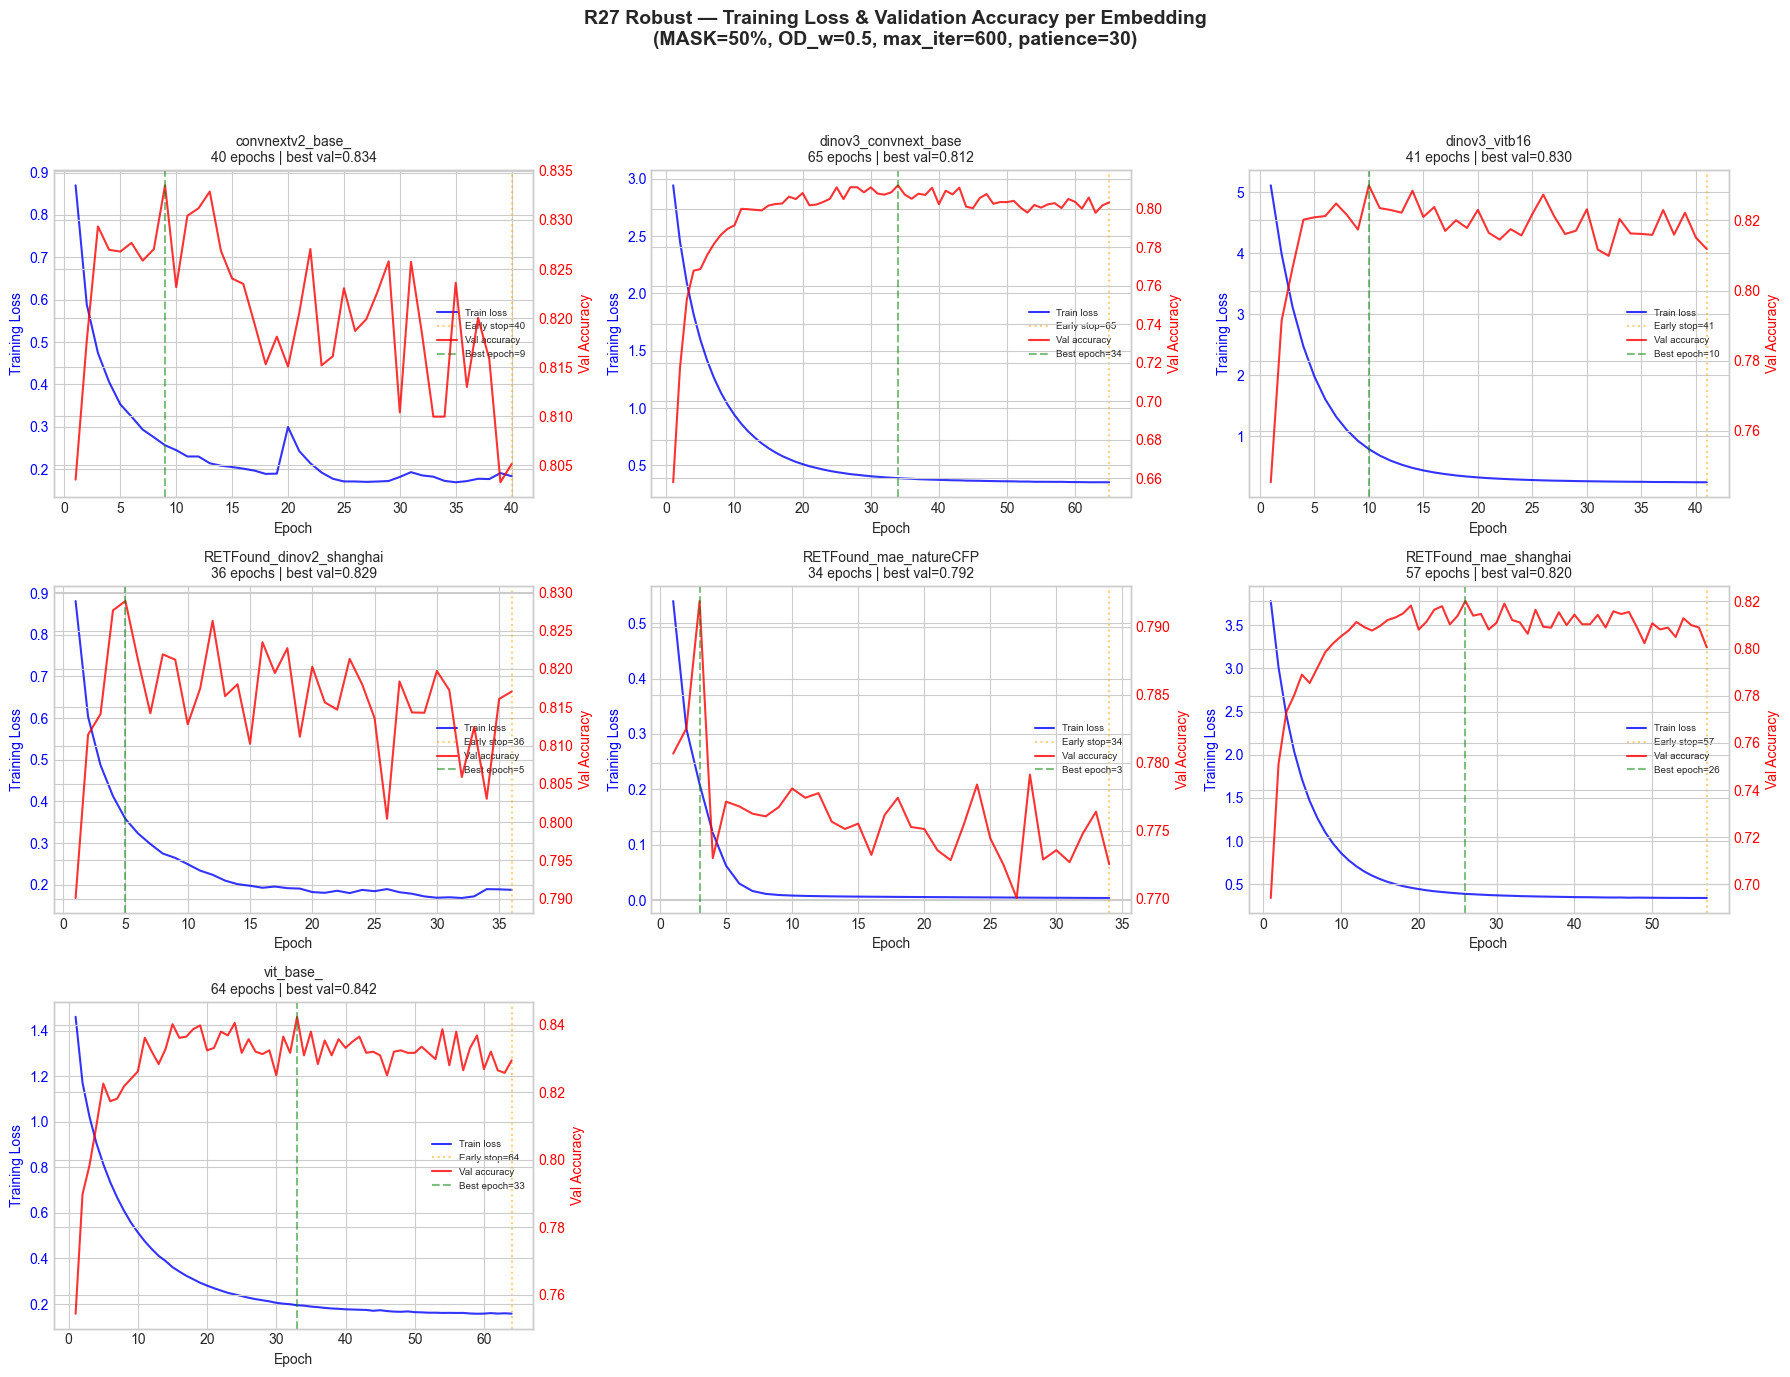


── Loss Curve Summary ──
Embedding                       Epochs  Early?  Final Loss  Best Val  Best Ep  Converged?
──────────────────────────────────────────────────────────────────────────────────────────
convnextv2_base_                    40    True      0.1832    0.8335        9         Yes
dinov3_convnext_base                65    True      0.3521    0.8122       34         Yes
dinov3_vitb16                       41    True      0.2474    0.8300       10     Still ↓
RETFound_dinov2_shanghai            36    True      0.1878    0.8289        5         Yes
RETFound_mae_natureCFP              34    True      0.0037    0.7919        3     Still ↓
RETFound_mae_shanghai               57    True      0.3422    0.8201       26         Yes
vit_base_                           64    True      0.1580    0.8424       33         Yes

── Overfitting Diagnostic ──
  convnextv2_base_: best@epoch 9/40 (78% after peak) | val drop=-0.0284 | ⚠ val peaked early → likely overfitting after best epoch
  

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# R27 — Training / Validation Loss Curves (Generalization Check)
# ═══════════════════════════════════════════════════════════════════════
# Trains ONE model per embedding using saved best HPs from R27-robust.
# Captures sklearn MLPClassifier loss_curve_ and validation_scores_
# to verify whether models are converging and generalizing properly.
# ═══════════════════════════════════════════════════════════════════════

import json, time
import matplotlib.pyplot as plt
from ast import literal_eval

R27_ROBUST_DIR = RESULTS_DIR.parent / 'brset_glaucoma_r27_masked_opticdisc_robust'

# R27 config (same as R27 cell)
R27_P_MASK_BASE = 0.50
R27_OD_CORRUPT  = 0.10
R27_OD_FEATURE_WEIGHT = 0.50
R27_OD_MISS_WEIGHT    = 0.50

R27_METADATA_COLS = {
    'age':      'numeric',
    'sex':      'passthrough',
    'diabetes': 'binary_yn',
    'exam_eye': 'binary',
    'camera':   'camera',
}

def _r27_bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _r27_mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _r27_bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _r27_apply_od_feature_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2:
        return X_s
    if od_w != 1.0:
        X_s[:, -2] *= od_w
    if miss_w != 1.0:
        X_s[:, -1] *= miss_w
    return X_s

# ─── Collect loss curves for all 7 embeddings ─────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes_flat = axes.flatten()

all_curves = {}

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    hp_file = R27_ROBUST_DIR / f'{emb_idx:02d}_{sname}' / 'hyperparameters.json'
    
    if not hp_file.exists():
        print(f'  [{emb_idx}] {sname}: no hyperparameters.json — skipped')
        continue
    
    with open(hp_file) as f:
        hp = json.load(f)
    
    arch = literal_eval(hp['architecture'])
    alpha = hp['alpha']
    lr = hp['lr']
    bs = hp['batch_size']
    pw = hp['pos_class_weight']
    
    print(f'[{emb_idx+1}/7] {sname} | arch={arch} lr={lr:.6f} w={pw:.2f}')
    
    # ── Data prep (same as R27) ──
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)
    
    train_df = df[df['patient_id'].isin(train_patient_ids)].dropna(subset=[TASK]).copy()
    
    X_tr_emb = train_df[ds.feature_cols].to_numpy(dtype=np.float32)
    y_train  = train_df[TASK].to_numpy(dtype=int)
    pids_tr  = train_df['patient_id'].to_numpy()
    
    # PCA (skip MI selection — R27 keeps all 384 components anyway)
    nc = min(PCA_COMPONENTS, X_tr_emb.shape[1], X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_sel = pca.fit_transform(X_tr_emb)
    
    # Metadata
    X_tr_meta, _ = encode_metadata(train_df, R27_METADATA_COLS)
    
    # optic_disc masking
    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _r27_mask_od(train_df['optic_disc'], R27_P_MASK_BASE, rng_hp, p_corrupt=R27_OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    
    # Scale + weight
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _r27_apply_od_feature_weights(X_tr_s, R27_OD_FEATURE_WEIGHT, R27_OD_MISS_WEIGHT)
    
    # ── Train single MLP with verbose loss tracking ──
    mlp = MLPClassifier(
        hidden_layer_sizes=arch, alpha=alpha,
        learning_rate='adaptive',                  # ← halves LR when val stalls
        learning_rate_init=lr, batch_size=bs,
        max_iter=MLP_MAX_ITER, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
        random_state=RANDOM_SEED,
    )
    sw = make_sample_weights(y_train, pw)
    mlp.fit(X_tr_s, y_train, sample_weight=sw)
    
    # ── Extract curves ──
    train_loss = mlp.loss_curve_
    val_scores = mlp.validation_scores_  # accuracy on held-out 15%
    n_epochs = len(train_loss)
    stopped_early = n_epochs < MLP_MAX_ITER
    
    all_curves[sname] = {
        'train_loss': train_loss,
        'val_scores': val_scores,
        'n_epochs': n_epochs,
        'stopped_early': stopped_early,
        'best_val': max(val_scores) if val_scores else None,
    }
    
    print(f'  Epochs: {n_epochs}/{MLP_MAX_ITER} | '
          f'Early stop: {stopped_early} | '
          f'Final loss: {train_loss[-1]:.4f} | '
          f'Best val acc: {max(val_scores):.4f}')
    
    # ── Plot ──
    ax = axes_flat[emb_idx]
    epochs = range(1, n_epochs + 1)
    
    ax.plot(epochs, train_loss, 'b-', linewidth=1.5, label='Train loss', alpha=0.8)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Training Loss', color='b', fontsize=10)
    ax.tick_params(axis='y', labelcolor='b')
    
    ax2 = ax.twinx()
    ax2.plot(epochs, val_scores, 'r-', linewidth=1.5, label='Val accuracy', alpha=0.8)
    ax2.set_ylabel('Val Accuracy', color='r', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='r')
    
    best_epoch = np.argmax(val_scores) + 1
    ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best epoch={best_epoch}')
    
    if stopped_early:
        ax.axvline(x=n_epochs, color='orange', linestyle=':', alpha=0.5, label=f'Early stop={n_epochs}')
    
    ax.set_title(f'{sname}\n{n_epochs} epochs | best val={max(val_scores):.3f}', fontsize=10)
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='center right')

# Hide unused subplots
for idx in range(len(embedding_files), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('R27 Robust — Training Loss & Validation Accuracy per Embedding\n'
             f'(MASK={R27_P_MASK_BASE:.0%}, OD_w={R27_OD_FEATURE_WEIGHT}, max_iter={MLP_MAX_ITER}, patience={MLP_PATIENCE})',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(R27_ROBUST_DIR / 'r27_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary table ────────────────────────────────────────────────
print('\n── Loss Curve Summary ──')
print(f'{"Embedding":<30} {"Epochs":>7} {"Early?":>7} {"Final Loss":>11} {"Best Val":>9} {"Best Ep":>8} {"Converged?":>11}')
print('─' * 90)
for sname, c in all_curves.items():
    best_ep = np.argmax(c['val_scores']) + 1
    # Check if converged: loss decreased in last 10% of epochs
    n = c['n_epochs']
    last_10 = c['train_loss'][max(0, n-n//10):]
    converged = 'Yes' if (last_10[0] - last_10[-1]) < 0.01 * last_10[0] else 'Still ↓'
    print(f'{sname:<30} {c["n_epochs"]:>7} {str(c["stopped_early"]):>7} '
          f'{c["train_loss"][-1]:>11.4f} {c["best_val"]:>9.4f} {best_ep:>8} {converged:>11}')

# ─── Overfitting diagnostic ──────────────────────────────────────
print('\n── Overfitting Diagnostic ──')
for sname, c in all_curves.items():
    n = c['n_epochs']
    best_ep = np.argmax(c['val_scores']) + 1
    gap_pct = (n - best_ep) / n * 100
    final_vs_best = c['val_scores'][-1] - max(c['val_scores'])
    
    if gap_pct > 30:
        status = '⚠ val peaked early → likely overfitting after best epoch'
    elif c['stopped_early'] and gap_pct < 15:
        status = '✓ early stopping near peak → good generalization'
    else:
        status = '● moderate — check if more epochs would help'
    
    print(f'  {sname}: best@epoch {best_ep}/{n} ({gap_pct:.0f}% after peak) | '
          f'val drop={final_vs_best:+.4f} | {status}')

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# Cell — Extra metrics: Balanced accuracy + Sensitivity (Class 1)
# ═══════════════════════════════════════════════════════════════════════
# Robust to kernel restarts: loads the latest saved P25 predictions.

from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, recall_score

BASE_DIR = Path.cwd()
R27_DIR = BASE_DIR / 'results' / 'brset_glaucoma_r27_masked_opticdisc_robust'
if not R27_DIR.exists():
    raise FileNotFoundError(f'R27 results folder not found: {R27_DIR}')

run_dirs = [p for p in R27_DIR.iterdir() if p.is_dir()]
if not run_dirs:
    raise FileNotFoundError(f'No embedding run folders found in: {R27_DIR}')

latest_run = max(run_dirs, key=lambda p: p.stat().st_mtime)
pred_path = latest_run / 'eye_predictions_P25.csv'
if not pred_path.exists():
    raise FileNotFoundError(f'Missing predictions file: {pred_path}')

pred_df = pd.read_csv(pred_path)
required_cols = {'eye_unit', 'y_true', 'y_pred', 'y_proba'}
missing = sorted(required_cols - set(pred_df.columns))
if missing:
    raise ValueError(f'eye_predictions_P25.csv missing columns: {missing}')

# --- Eye-level ---
y_true_eye = pred_df['y_true'].to_numpy(dtype=int)
y_pred_eye = pred_df['y_pred'].to_numpy(dtype=int)

bal_acc_eye = float(balanced_accuracy_score(y_true_eye, y_pred_eye))
sens_eye = float(recall_score(y_true_eye, y_pred_eye, pos_label=1, zero_division=0))
spec_eye = float(recall_score(y_true_eye, y_pred_eye, pos_label=0, zero_division=0))

print(f'Loaded: {pred_path}')
print('P25 — Eye-level metrics')
print(f'  Balanced accuracy : {bal_acc_eye:.4f}')
print(f'  Sensitivity (cls1): {sens_eye:.4f}')
print(f'  Specificity (cls0): {spec_eye:.4f}')

# --- Patient-level (any-eye positive) derived from eye predictions ---
pred_df['patient_id'] = pred_df['eye_unit'].astype(str).str.split('_eye', n=1).str[0]
pat_true = pred_df.groupby('patient_id')['y_true'].max().to_numpy(dtype=int)
pat_pred = pred_df.groupby('patient_id')['y_pred'].max().to_numpy(dtype=int)

bal_acc_pat = float(balanced_accuracy_score(pat_true, pat_pred))
sens_pat = float(recall_score(pat_true, pat_pred, pos_label=1, zero_division=0))
spec_pat = float(recall_score(pat_true, pat_pred, pos_label=0, zero_division=0))

print('P25 — Patient-level metrics (any-eye positive)')
print(f'  Balanced accuracy : {bal_acc_pat:.4f}')
print(f'  Sensitivity (cls1): {sens_pat:.4f}')
print(f'  Specificity (cls0): {spec_pat:.4f}')

Loaded: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_glaucoma_r27_masked_opticdisc_robust\06_vit_base_\eye_predictions_P25.csv
P25 — Eye-level metrics
  Balanced accuracy : 0.8774
  Sensitivity (cls1): 0.8250
  Specificity (cls0): 0.9298
P25 — Patient-level metrics (any-eye positive)
  Balanced accuracy : 0.8785
  Sensitivity (cls1): 0.8657
  Specificity (cls0): 0.8913


In [13]:
# ═══════════════════════════════════════════════════════════════════════
# Cell — Summary across embeddings: Balanced accuracy + Sensitivity (P25)
# ═══════════════════════════════════════════════════════════════════════

from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, recall_score, f1_score

BASE_DIR = Path.cwd()
R27_DIR = BASE_DIR / 'results' / 'brset_glaucoma_r27_masked_opticdisc_robust'
if not R27_DIR.exists():
    raise FileNotFoundError(f'R27 results folder not found: {R27_DIR}')

rows = []
for run_dir in sorted([p for p in R27_DIR.iterdir() if p.is_dir()]):
    pred_path = run_dir / 'eye_predictions_P25.csv'
    if not pred_path.exists():
        continue
    pred_df = pd.read_csv(pred_path)
    if not {'eye_unit', 'y_true', 'y_pred'}.issubset(pred_df.columns):
        continue

    y_true_eye = pred_df['y_true'].to_numpy(dtype=int)
    y_pred_eye = pred_df['y_pred'].to_numpy(dtype=int)
    bal_acc_eye = float(balanced_accuracy_score(y_true_eye, y_pred_eye))
    sens_eye = float(recall_score(y_true_eye, y_pred_eye, pos_label=1, zero_division=0))
    spec_eye = float(recall_score(y_true_eye, y_pred_eye, pos_label=0, zero_division=0))
    f1_eye = float(f1_score(y_true_eye, y_pred_eye, zero_division=0))

    pred_df['patient_id'] = pred_df['eye_unit'].astype(str).str.split('_eye', n=1).str[0]
    pat_true = pred_df.groupby('patient_id')['y_true'].max().to_numpy(dtype=int)
    pat_pred = pred_df.groupby('patient_id')['y_pred'].max().to_numpy(dtype=int)
    bal_acc_pat = float(balanced_accuracy_score(pat_true, pat_pred))
    sens_pat = float(recall_score(pat_true, pat_pred, pos_label=1, zero_division=0))
    spec_pat = float(recall_score(pat_true, pat_pred, pos_label=0, zero_division=0))
    f1_pat = float(f1_score(pat_true, pat_pred, zero_division=0))

    rows.append({
        'run': run_dir.name,
        'f1_eye': f1_eye,
        'bal_acc_eye': bal_acc_eye,
        'sens_eye': sens_eye,
        'spec_eye': spec_eye,
        'f1_pat_any_eye': f1_pat,
        'bal_acc_pat_any_eye': bal_acc_pat,
        'sens_pat_any_eye': sens_pat,
        'spec_pat_any_eye': spec_pat,
        'pred_path': str(pred_path),
    })

if not rows:
    raise RuntimeError(f'No P25 prediction files found under {R27_DIR}')

sum_df = pd.DataFrame(rows)
sum_df = sum_df.sort_values(['sens_eye', 'f1_eye'], ascending=False).reset_index(drop=True)

display_cols = [
    'run',
    'f1_eye', 'bal_acc_eye', 'sens_eye', 'spec_eye',
    'f1_pat_any_eye', 'bal_acc_pat_any_eye', 'sens_pat_any_eye', 'spec_pat_any_eye',
    'pred_path',
 ]
print('R27 P25 summary across embeddings (sorted by eye sensitivity, then eye F1)')
print(sum_df[display_cols].to_string(index=False))

R27 P25 summary across embeddings (sorted by eye sensitivity, then eye F1)
                        run   f1_eye  bal_acc_eye  sens_eye  spec_eye  f1_pat_any_eye  bal_acc_pat_any_eye  sens_pat_any_eye  spec_pat_any_eye                                                                                                                                                                                             pred_path
               06_vit_base_ 0.785507     0.877403  0.824962  0.929845        0.786492             0.878506          0.865707          0.891304                c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_glaucoma_r27_masked_opticdisc_robust\06_vit_base_\eye_predictions_P25.csv
    01_dinov3_convnext_base 0.804805     0.880977  0.815830  0.946124        0.817469             0.894560          0.875300          0.913820     c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\r